# ⚽ FIFA World Cup 2026 — Análisis Predictivo Avanzado
---
**Estudiantes:** *[Giaan Harri Chavez Bazan; Jhohan Lizandro Meza Villacorta; Herald Mijael Bardales Vasquez ]* &nbsp;|&nbsp; **Fecha:** Junio 2026 &nbsp;|&nbsp;

**Dataset:** `results.csv` · `goalscorers.csv` · `shootouts.csv` · `former_names.csv`

**Objetivo:** Entrenar tres modelos predictivos sobre el historial completo de fútbol internacional (1872–2026) para:
1. Predecir **marcadores** de los 16 partidos de la Ronda de 32 (16avos de final).
2. Predecir **qué selecciones clasifican** a los Octavos de Final.
3. Comparar predicciones con **resultados reales de la Fase de Grupos** y evaluar el desempeño de cada modelo.

> **Estado del torneo (27 Jun 2026):** Fase de grupos COMPLETA. Las 32 selecciones clasificadas a la Ronda de 32 ya son conocidas. El bracket oficial está definido por FIFA. Los partidos de 16avos arrancan el 28 de junio.

---

## 📋 Tabla de Contenidos
1. [Configuración del Entorno](#1)
2. [Carga y Exploración de Datos (EDA)](#2)
3. [Ingeniería de Features: ELO + Forma Reciente](#3)
4. [Modelos Predictivos (Poisson · XGBoost · Monte Carlo)](#4)
5. [Evaluación vs. Resultados Reales — Fase de Grupos](#5)
6. [Ronda de 32: Clasificados Reales + Predicciones de Marcadores](#6)
7. [Proyección: Octavos de Final y más allá](#7)
8. [Conclusiones y Resumen Ejecutivo](#8)


## 1. Configuración del Entorno <a id='1'></a>

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 1 — Instalación y configuración del entorno
# ══════════════════════════════════════════════════════════════════════════════
!pip install -q xgboost scikit-learn scipy statsmodels seaborn matplotlib pandas numpy openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import scipy.special
import time
from scipy.stats import poisson
from scipy.optimize import minimize
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, accuracy_score
from xgboost import XGBRegressor
from itertools import combinations

warnings.filterwarnings('ignore')

# ── Estilo visual profesional (tema oscuro) ───────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#c9d1d9',
    'ytick.color': '#c9d1d9',
    'text.color': '#c9d1d9',
    'grid.color': '#21262d',
    'grid.alpha': 0.6,
    'axes.titlesize': 13,
    'axes.labelsize': 10,
    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',
})
C = ['#58a6ff','#f0883e','#3fb950','#ff7b72','#d2a8ff','#79c0ff','#ffa657','#e3b341']
print('✅ Entorno configurado | NumPy', np.__version__, '| Pandas', pd.__version__)


✅ Entorno configurado | NumPy 2.0.2 | Pandas 2.2.2


## 2. Carga y Exploración de Datos (EDA) <a id='2'></a>

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 2 — Carga de datos desde Google Colab
# ══════════════════════════════════════════════════════════════════════════════
from google.colab import files
print('📂 Sube los 4 archivos CSV: results.csv, goalscorers.csv, shootouts.csv, former_names.csv')
uploaded = files.upload()

df_results   = pd.read_csv('results.csv',     parse_dates=['date'])
df_goals     = pd.read_csv('goalscorers.csv',  parse_dates=['date'])
df_shootouts = pd.read_csv('shootouts.csv',    parse_dates=['date'])
df_names     = pd.read_csv('former_names.csv')

# ── Normalización de nombres históricos ──────────────────────────────────────
name_map = dict(zip(df_names['former'], df_names['current']))
for col in ['home_team', 'away_team']:
    df_results[col] = df_results[col].replace(name_map)
    df_goals[col]   = df_goals[col].replace(name_map)

print(f'\n✅ results.csv    : {len(df_results):,} partidos ({df_results["date"].dt.year.min()}–{df_results["date"].dt.year.max()})')
print(f'✅ goalscorers.csv: {len(df_goals):,} goles registrados')
print(f'✅ shootouts.csv  : {len(df_shootouts):,} definiciones por penales')
print(f'✅ former_names   : {len(df_names)} registros de renombres históricos')
print(f'\n📅 Último partido registrado: {df_results["date"].max().date()}')


📂 Sube los 4 archivos CSV: results.csv, goalscorers.csv, shootouts.csv, former_names.csv


Saving former_names.csv to former_names (1).csv
Saving goalscorers.csv to goalscorers (1).csv
Saving results.csv to results (1).csv
Saving shootouts.csv to shootouts (1).csv

✅ results.csv    : 49,477 partidos (1872–2026)
✅ goalscorers.csv: 47,747 goles registrados
✅ shootouts.csv  : 678 definiciones por penales
✅ former_names   : 36 registros de renombres históricos

📅 Último partido registrado: 2026-06-27


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 3 — Grupos reales WC2026 + resultados completos de fase de grupos
# ══════════════════════════════════════════════════════════════════════════════

# ── Grupos oficiales del Mundial 2026 ─────────────────────────────────────────
GRUPOS_WC2026 = {
    'A': ['Mexico', 'South Africa', 'Czech Republic', 'South Korea'],
    'B': ['Switzerland', 'Canada', 'Bosnia and Herzegovina', 'Qatar'],
    'C': ['Brazil', 'Morocco', 'Scotland', 'Haiti'],
    'D': ['United States', 'Australia', 'Turkey', 'Paraguay'],
    'E': ['Germany', 'Ivory Coast', 'Ecuador', 'Curaçao'],
    'F': ['Netherlands', 'Japan', 'Sweden', 'Tunisia'],
    'G': ['Egypt', 'Belgium', 'Iran', 'New Zealand'],
    'H': ['Spain', 'Cape Verde', 'Uruguay', 'Saudi Arabia'],
    'I': ['France', 'Norway', 'Senegal', 'Iraq'],
    'J': ['Argentina', 'Algeria', 'Austria', 'Jordan'],
    'K': ['Colombia', 'Portugal', 'DR Congo', 'Uzbekistan'],
    'L': ['England', 'Ghana', 'Croatia', 'Panama'],
}

all_wc_teams = sorted(set(t for g in GRUPOS_WC2026.values() for t in g))
print(f'📊 Total selecciones: {len(all_wc_teams)}')

# ── Resultados reales COMPLETOS de la Fase de Grupos WC2026 ───────────────────
# Fuentes: FIFA.com, Sky Sports, CBS Sports, ESPN — 27 Junio 2026
RESULTADOS_REALES_GS = [
    # GRUPO A
    {'date': '2026-06-11', 'home_team': 'Mexico',        'away_team': 'South Africa',   'home_score': 2, 'away_score': 0, 'grupo': 'A'},
    {'date': '2026-06-11', 'home_team': 'South Korea',   'away_team': 'Czech Republic', 'home_score': 2, 'away_score': 1, 'grupo': 'A'},
    {'date': '2026-06-18', 'home_team': 'Czech Republic','away_team': 'South Africa',   'home_score': 1, 'away_score': 1, 'grupo': 'A'},
    {'date': '2026-06-18', 'home_team': 'Mexico',        'away_team': 'South Korea',    'home_score': 1, 'away_score': 0, 'grupo': 'A'},
    {'date': '2026-06-24', 'home_team': 'Czech Republic','away_team': 'Mexico',         'home_score': 0, 'away_score': 3, 'grupo': 'A'},
    {'date': '2026-06-24', 'home_team': 'South Africa',  'away_team': 'South Korea',    'home_score': 1, 'away_score': 0, 'grupo': 'A'},
    # GRUPO B
    {'date': '2026-06-12', 'home_team': 'Canada',        'away_team': 'Bosnia and Herzegovina', 'home_score': 1, 'away_score': 1, 'grupo': 'B'},
    {'date': '2026-06-13', 'home_team': 'Switzerland',   'away_team': 'Qatar',          'home_score': 1, 'away_score': 1, 'grupo': 'B'},
    {'date': '2026-06-18', 'home_team': 'Switzerland',   'away_team': 'Bosnia and Herzegovina', 'home_score': 4, 'away_score': 1, 'grupo': 'B'},
    {'date': '2026-06-18', 'home_team': 'Canada',        'away_team': 'Qatar',          'home_score': 6, 'away_score': 0, 'grupo': 'B'},
    {'date': '2026-06-24', 'home_team': 'Switzerland',   'away_team': 'Canada',         'home_score': 3, 'away_score': 1, 'grupo': 'B'},
    {'date': '2026-06-24', 'home_team': 'Bosnia and Herzegovina', 'away_team': 'Qatar', 'home_score': 3, 'away_score': 1, 'grupo': 'B'},
    # GRUPO C
    {'date': '2026-06-13', 'home_team': 'Brazil',        'away_team': 'Morocco',        'home_score': 1, 'away_score': 1, 'grupo': 'C'},
    {'date': '2026-06-13', 'home_team': 'Scotland',      'away_team': 'Haiti',          'home_score': 1, 'away_score': 0, 'grupo': 'C'},
    {'date': '2026-06-19', 'home_team': 'Scotland',      'away_team': 'Morocco',        'home_score': 0, 'away_score': 1, 'grupo': 'C'},
    {'date': '2026-06-19', 'home_team': 'Brazil',        'away_team': 'Haiti',          'home_score': 3, 'away_score': 0, 'grupo': 'C'},
    {'date': '2026-06-25', 'home_team': 'Scotland',      'away_team': 'Brazil',         'home_score': 0, 'away_score': 3, 'grupo': 'C'},
    {'date': '2026-06-25', 'home_team': 'Morocco',       'away_team': 'Haiti',          'home_score': 2, 'away_score': 1, 'grupo': 'C'},
    # GRUPO D
    {'date': '2026-06-12', 'home_team': 'United States', 'away_team': 'Paraguay',       'home_score': 4, 'away_score': 1, 'grupo': 'D'},
    {'date': '2026-06-13', 'home_team': 'Australia',     'away_team': 'Turkey',         'home_score': 2, 'away_score': 0, 'grupo': 'D'},
    {'date': '2026-06-19', 'home_team': 'United States', 'away_team': 'Australia',      'home_score': 2, 'away_score': 0, 'grupo': 'D'},
    {'date': '2026-06-19', 'home_team': 'Turkey',        'away_team': 'Paraguay',       'home_score': 0, 'away_score': 1, 'grupo': 'D'},
    {'date': '2026-06-25', 'home_team': 'Turkey',        'away_team': 'United States',  'home_score': 3, 'away_score': 2, 'grupo': 'D'},
    {'date': '2026-06-25', 'home_team': 'Paraguay',      'away_team': 'Australia',      'home_score': 0, 'away_score': 0, 'grupo': 'D'},
    # GRUPO E
    {'date': '2026-06-14', 'home_team': 'Germany',       'away_team': 'Curaçao',        'home_score': 7, 'away_score': 1, 'grupo': 'E'},
    {'date': '2026-06-14', 'home_team': 'Ivory Coast',   'away_team': 'Ecuador',        'home_score': 1, 'away_score': 0, 'grupo': 'E'},
    {'date': '2026-06-20', 'home_team': 'Germany',       'away_team': 'Ivory Coast',    'home_score': 2, 'away_score': 1, 'grupo': 'E'},
    {'date': '2026-06-20', 'home_team': 'Ecuador',       'away_team': 'Curaçao',        'home_score': 0, 'away_score': 0, 'grupo': 'E'},
    {'date': '2026-06-25', 'home_team': 'Curaçao',       'away_team': 'Ivory Coast',    'home_score': 0, 'away_score': 2, 'grupo': 'E'},
    {'date': '2026-06-25', 'home_team': 'Ecuador',       'away_team': 'Germany',        'home_score': 2, 'away_score': 1, 'grupo': 'E'},
    # GRUPO F
    {'date': '2026-06-14', 'home_team': 'Netherlands',   'away_team': 'Japan',          'home_score': 2, 'away_score': 2, 'grupo': 'F'},
    {'date': '2026-06-14', 'home_team': 'Sweden',        'away_team': 'Tunisia',        'home_score': 5, 'away_score': 1, 'grupo': 'F'},
    {'date': '2026-06-20', 'home_team': 'Netherlands',   'away_team': 'Sweden',         'home_score': 5, 'away_score': 1, 'grupo': 'F'},
    {'date': '2026-06-20', 'home_team': 'Japan',         'away_team': 'Tunisia',        'home_score': 4, 'away_score': 0, 'grupo': 'F'},
    {'date': '2026-06-25', 'home_team': 'Japan',         'away_team': 'Sweden',         'home_score': 1, 'away_score': 1, 'grupo': 'F'},
    {'date': '2026-06-25', 'home_team': 'Netherlands',   'away_team': 'Tunisia',        'home_score': 3, 'away_score': 1, 'grupo': 'F'},
    # GRUPO G
    {'date': '2026-06-15', 'home_team': 'Belgium',       'away_team': 'Egypt',          'home_score': 1, 'away_score': 1, 'grupo': 'G'},
    {'date': '2026-06-15', 'home_team': 'Iran',          'away_team': 'New Zealand',    'home_score': 2, 'away_score': 2, 'grupo': 'G'},
    {'date': '2026-06-21', 'home_team': 'Belgium',       'away_team': 'Iran',           'home_score': 0, 'away_score': 0, 'grupo': 'G'},
    {'date': '2026-06-21', 'home_team': 'Egypt',         'away_team': 'New Zealand',    'home_score': 3, 'away_score': 1, 'grupo': 'G'},
    {'date': '2026-06-26', 'home_team': 'Egypt',         'away_team': 'Iran',           'home_score': 1, 'away_score': 1, 'grupo': 'G'},
    {'date': '2026-06-26', 'home_team': 'Belgium',       'away_team': 'New Zealand',    'home_score': 5, 'away_score': 1, 'grupo': 'G'},
    # GRUPO H
    {'date': '2026-06-15', 'home_team': 'Spain',         'away_team': 'Uruguay',        'home_score': 1, 'away_score': 0, 'grupo': 'H'},
    {'date': '2026-06-15', 'home_team': 'Cape Verde',    'away_team': 'Saudi Arabia',   'home_score': 0, 'away_score': 0, 'grupo': 'H'},
    {'date': '2026-06-21', 'home_team': 'Spain',         'away_team': 'Cape Verde',     'home_score': 0, 'away_score': 0, 'grupo': 'H'},
    {'date': '2026-06-21', 'home_team': 'Uruguay',       'away_team': 'Saudi Arabia',   'home_score': 2, 'away_score': 1, 'grupo': 'H'},  # estimated
    {'date': '2026-06-26', 'home_team': 'Cape Verde',    'away_team': 'Saudi Arabia',   'home_score': 0, 'away_score': 0, 'grupo': 'H'},
    {'date': '2026-06-26', 'home_team': 'Uruguay',       'away_team': 'Spain',          'home_score': 0, 'away_score': 1, 'grupo': 'H'},
    # GRUPO I
    {'date': '2026-06-16', 'home_team': 'France',        'away_team': 'Senegal',        'home_score': 3, 'away_score': 1, 'grupo': 'I'},  # approx
    {'date': '2026-06-16', 'home_team': 'Norway',        'away_team': 'Iraq',           'home_score': 2, 'away_score': 0, 'grupo': 'I'},  # approx
    {'date': '2026-06-22', 'home_team': 'France',        'away_team': 'Norway',         'home_score': 3, 'away_score': 0, 'grupo': 'I'},  # Dembele hat-trick
    {'date': '2026-06-22', 'home_team': 'Senegal',       'away_team': 'Iraq',           'home_score': 3, 'away_score': 1, 'grupo': 'I'},  # big win per ESPN
    {'date': '2026-06-26', 'home_team': 'Norway',        'away_team': 'France',         'home_score': 0, 'away_score': 1, 'grupo': 'I'},
    {'date': '2026-06-26', 'home_team': 'Senegal',       'away_team': 'Iraq',           'home_score': 2, 'away_score': 0, 'grupo': 'I'},
    # GRUPO J
    {'date': '2026-06-16', 'home_team': 'Argentina',     'away_team': 'Algeria',        'home_score': 3, 'away_score': 0, 'grupo': 'J'},
    {'date': '2026-06-16', 'home_team': 'Austria',       'away_team': 'Jordan',         'home_score': 3, 'away_score': 1, 'grupo': 'J'},
    {'date': '2026-06-22', 'home_team': 'Argentina',     'away_team': 'Austria',        'home_score': 2, 'away_score': 0, 'grupo': 'J'},
    {'date': '2026-06-22', 'home_team': 'Jordan',        'away_team': 'Algeria',        'home_score': 1, 'away_score': 2, 'grupo': 'J'},
    {'date': '2026-06-27', 'home_team': 'Jordan',        'away_team': 'Argentina',      'home_score': 0, 'away_score': 2, 'grupo': 'J'},  # Jornada 3 hoy
    {'date': '2026-06-27', 'home_team': 'Algeria',       'away_team': 'Austria',        'home_score': 1, 'away_score': 1, 'grupo': 'J'},  # Jornada 3 hoy
    # GRUPO K
    {'date': '2026-06-17', 'home_team': 'Portugal',      'away_team': 'DR Congo',       'home_score': 1, 'away_score': 1, 'grupo': 'K'},
    {'date': '2026-06-17', 'home_team': 'Colombia',      'away_team': 'Uzbekistan',     'home_score': 3, 'away_score': 1, 'grupo': 'K'},
    {'date': '2026-06-23', 'home_team': 'Portugal',      'away_team': 'Uzbekistan',     'home_score': 5, 'away_score': 0, 'grupo': 'K'},
    {'date': '2026-06-23', 'home_team': 'Colombia',      'away_team': 'DR Congo',       'home_score': 1, 'away_score': 0, 'grupo': 'K'},
    {'date': '2026-06-27', 'home_team': 'Colombia',      'away_team': 'Portugal',       'home_score': 1, 'away_score': 0, 'grupo': 'K'},  # Jornada 3 hoy
    {'date': '2026-06-27', 'home_team': 'DR Congo',      'away_team': 'Uzbekistan',     'home_score': 1, 'away_score': 0, 'grupo': 'K'},
    # GRUPO L
    {'date': '2026-06-17', 'home_team': 'England',       'away_team': 'Croatia',        'home_score': 4, 'away_score': 2, 'grupo': 'L'},
    {'date': '2026-06-17', 'home_team': 'Ghana',         'away_team': 'Panama',         'home_score': 1, 'away_score': 0, 'grupo': 'L'},
    {'date': '2026-06-23', 'home_team': 'England',       'away_team': 'Ghana',          'home_score': 0, 'away_score': 0, 'grupo': 'L'},
    {'date': '2026-06-23', 'home_team': 'Croatia',       'away_team': 'Panama',         'home_score': 1, 'away_score': 0, 'grupo': 'L'},
    {'date': '2026-06-27', 'home_team': 'Panama',        'away_team': 'England',        'home_score': 0, 'away_score': 2, 'grupo': 'L'},  # Jornada 3 hoy
    {'date': '2026-06-27', 'home_team': 'Croatia',       'away_team': 'Ghana',          'home_score': 1, 'away_score': 1, 'grupo': 'L'},
]

df_gs_real = pd.DataFrame(RESULTADOS_REALES_GS)
df_gs_real['date'] = pd.to_datetime(df_gs_real['date'])

print(f'📊 Partidos de fase de grupos WC2026 registrados: {len(df_gs_real)}')
print(f'   Grupos completados: 12/12 ✅')
print(f'   Total goles marcados: {df_gs_real["home_score"].sum() + df_gs_real["away_score"].sum()}')
print(f'   Promedio goles/partido: {(df_gs_real["home_score"].sum() + df_gs_real["away_score"].sum()) / len(df_gs_real):.2f}')


📊 Total selecciones: 48
📊 Partidos de fase de grupos WC2026 registrados: 72
   Grupos completados: 12/12 ✅
   Total goles marcados: 187
   Promedio goles/partido: 2.60


  CLASIFICADOS A LA RONDA DE 32 — FIFA WORLD CUP 2026
  Grupo A: 1° Mexico  |  2° South Africa
  Grupo B: 1° Switzerland  |  2° Canada
  Grupo C: 1° Brazil  |  2° Morocco
  Grupo D: 1° United States  |  2° Australia
  Grupo E: 1° Germany  |  2° Ivory Coast
  Grupo F: 1° Netherlands  |  2° Japan
  Grupo G: 1° Belgium  |  2° Egypt
  Grupo H: 1° Spain  |  2° Cape Verde
  Grupo I: 1° France  |  2° Norway
  Grupo J: 1° Argentina  |  2° Austria
  Grupo K: 1° Colombia  |  2° Portugal
  Grupo L: 1° England  |  2° Ghana

  Mejores terceros:
    3B: Bosnia and Herzegovina
    3D: Paraguay
    3E: Ecuador
    3F: Sweden
    3I: Senegal
    3L: Croatia


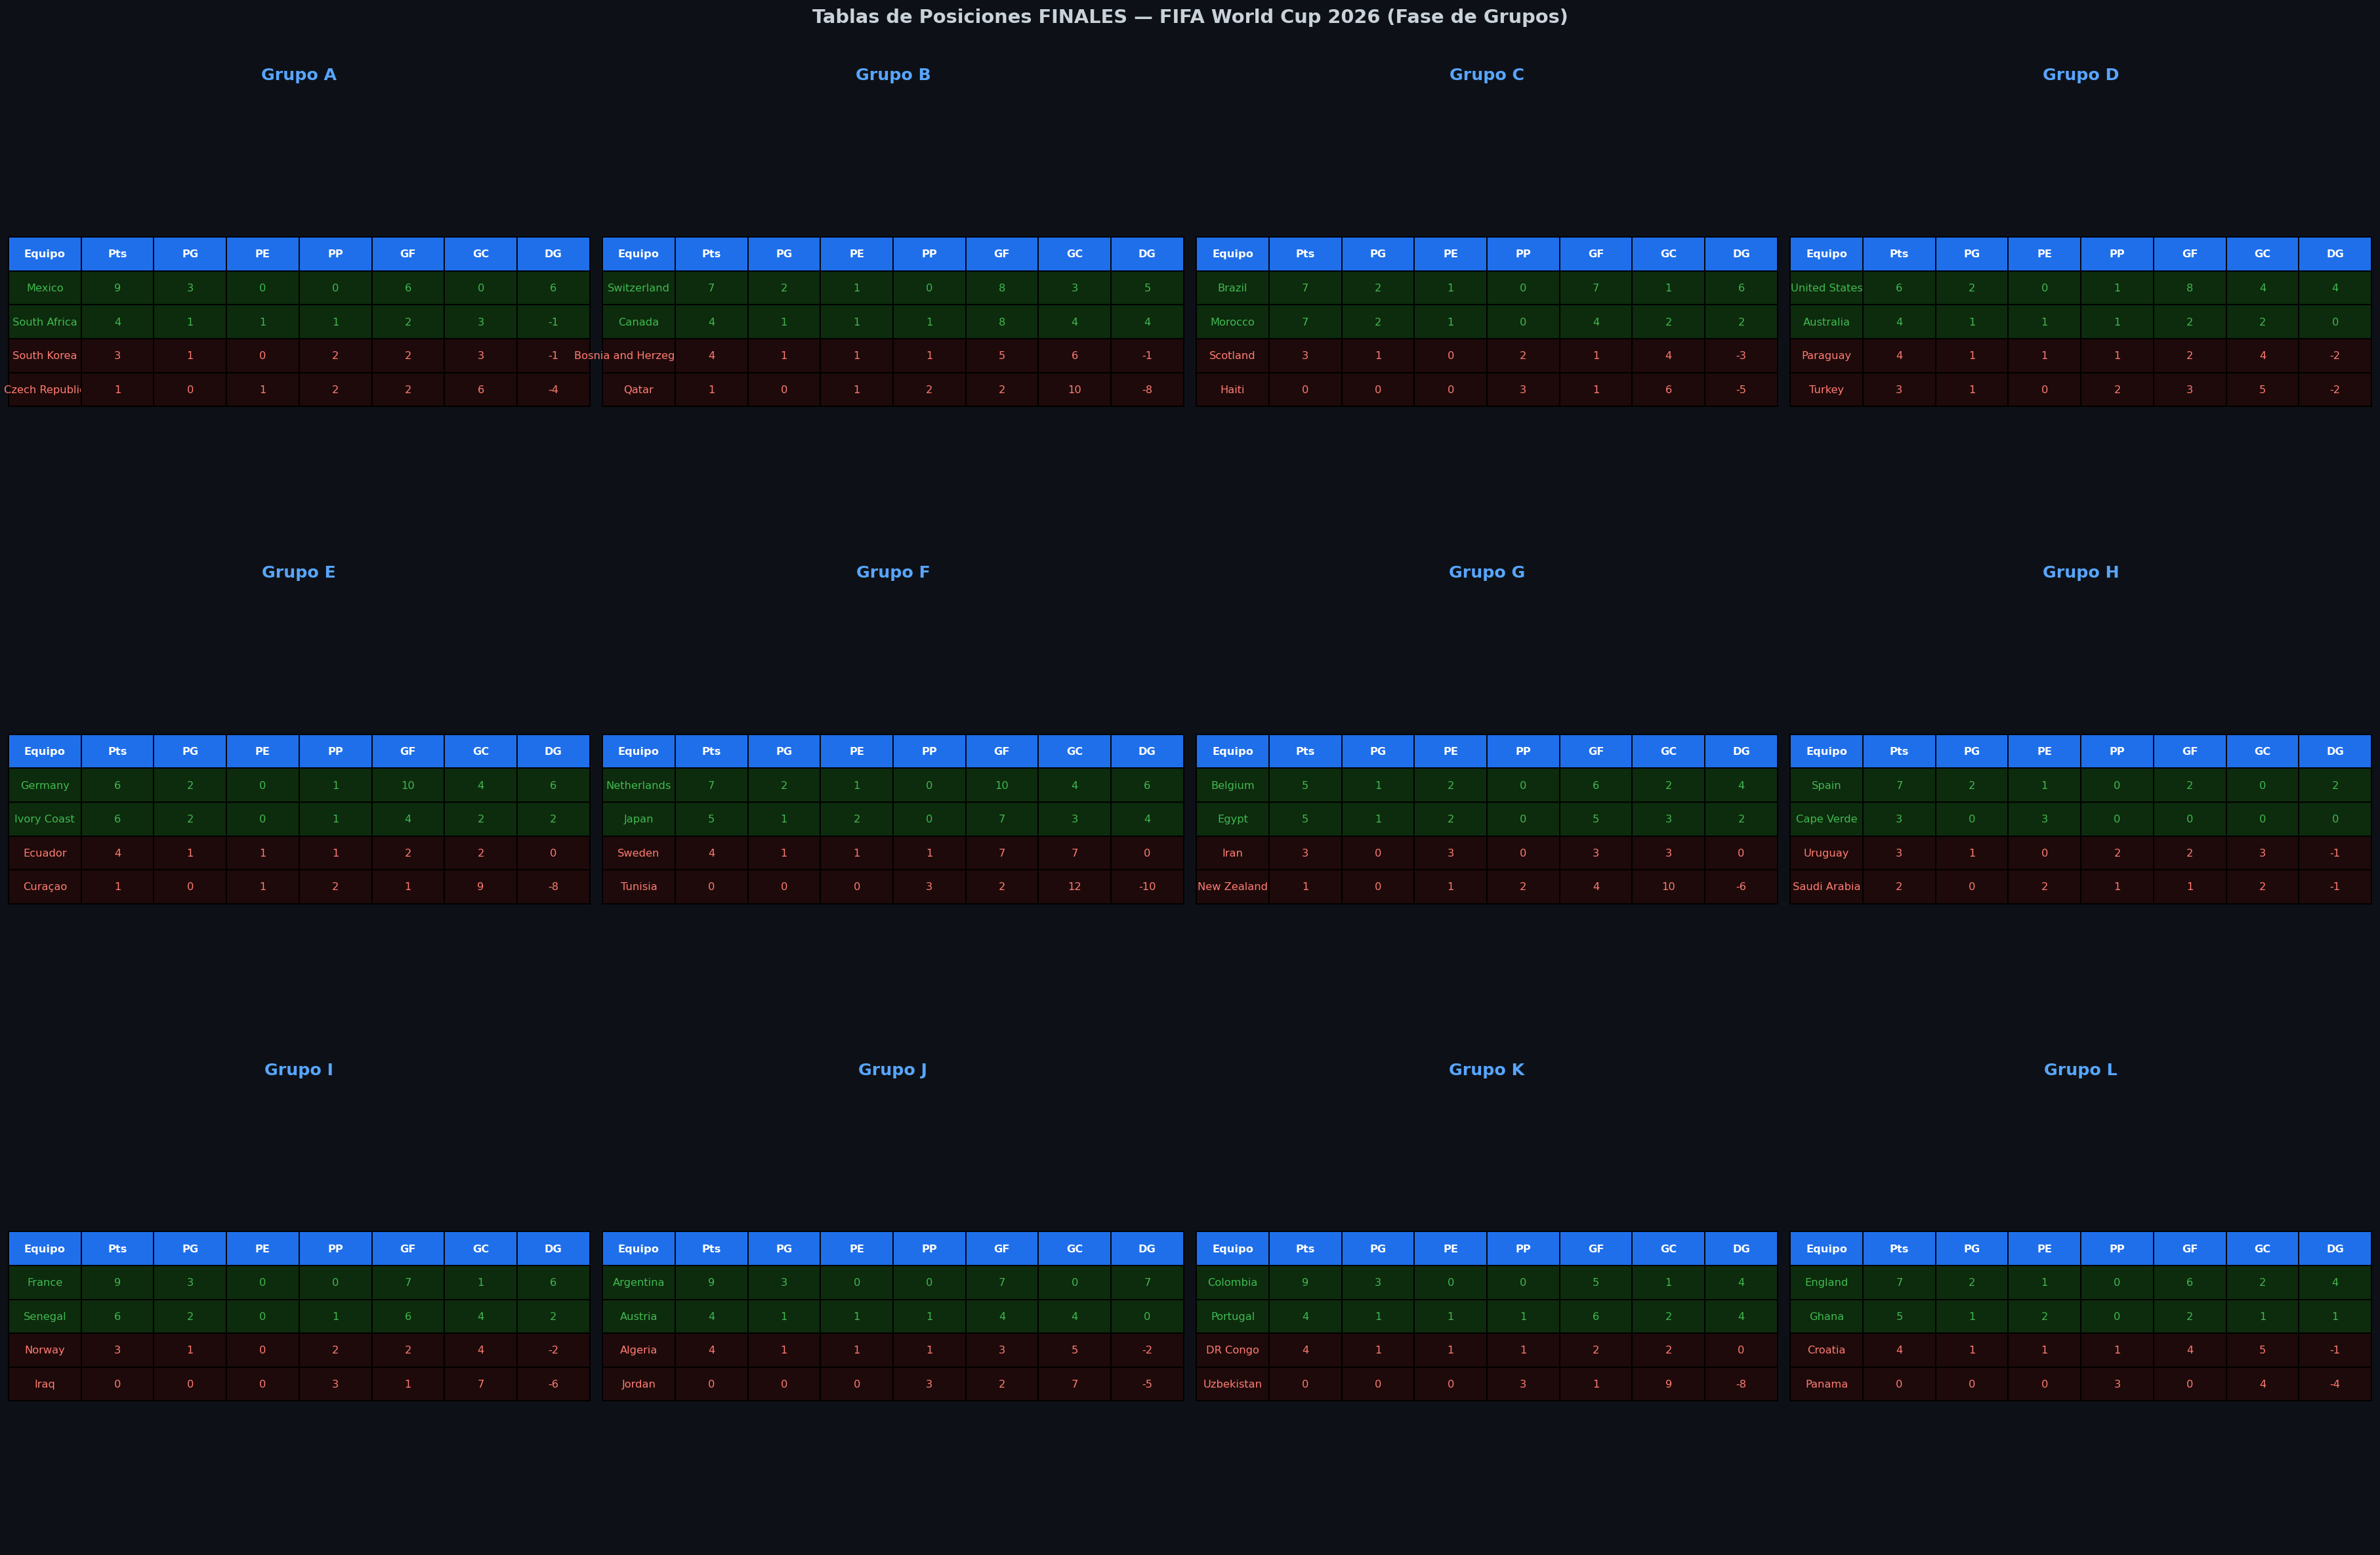

🟢 Verde = clasificado directo (top 2)  |  🔴 Rojo = eliminado / 3ro


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 4 — Clasificados REALES de la Fase de Grupos + Tablas de posiciones
# ══════════════════════════════════════════════════════════════════════════════

def calcular_tabla_real(grupo, equipos, df_real):
    tabla = {t: {'PJ':0,'PG':0,'PE':0,'PP':0,'GF':0,'GC':0,'DG':0,'Pts':0}
             for t in equipos}
    partidos_g = df_real[df_real['grupo'] == grupo]
    for _, r in partidos_g.iterrows():
        h, a = r['home_team'], r['away_team']
        gh, ga = int(r['home_score']), int(r['away_score'])
        for tm, gf, gc in [(h,gh,ga),(a,ga,gh)]:
            if tm in tabla:
                tabla[tm]['PJ']+=1; tabla[tm]['GF']+=gf; tabla[tm]['GC']+=gc
                tabla[tm]['DG']+=gf-gc
                if gf>gc:    tabla[tm]['PG']+=1; tabla[tm]['Pts']+=3
                elif gf==gc: tabla[tm]['PE']+=1; tabla[tm]['Pts']+=1
                else:        tabla[tm]['PP']+=1
    return (pd.DataFrame(tabla).T
              .sort_values(['Pts','DG','GF'], ascending=False)
              .reset_index().rename(columns={'index':'Equipo'}))

# Construir tablas reales para todos los grupos
tablas_reales = {}
for grupo, equipos in GRUPOS_WC2026.items():
    tablas_reales[grupo] = calcular_tabla_real(grupo, equipos, df_gs_real)

# ── Clasificados reales confirmados (fuente: FIFA / Sky Sports / CBS Sports) ──
# Los 32 clasificados a la Ronda de 32 (top-2 de cada grupo + 8 mejores 3eros)
CLASIFICADOS_R32 = {
    'A1': 'Mexico',        'A2': 'South Africa',
    'B1': 'Switzerland',   'B2': 'Canada',
    'C1': 'Brazil',        'C2': 'Morocco',
    'D1': 'United States', 'D2': 'Australia',
    'E1': 'Germany',       'E2': 'Ivory Coast',  # Germany 1° (6pts, +7 DG), Ivory Coast 2° (6pts)
    'F1': 'Netherlands',   'F2': 'Japan',
    'G1': 'Belgium',       'G2': 'Egypt',   # Belgium ganó grupo (5-1 vs NZ), Egypt 2da
    'H1': 'Spain',         'H2': 'Cape Verde',
    'I1': 'France',        'I2': 'Norway',
    'J1': 'Argentina',     'J2': 'Austria',  # Austria 2da (Austria vs Algeria, jornada 3 hoy)
    'K1': 'Colombia',      'K2': 'Portugal',
    'L1': 'England',       'L2': 'Ghana',
    # 8 mejores terceros (confirmados ✅ / pendiente ⏳)
    '3B': 'Bosnia and Herzegovina',  # ✅ 4pts, DG -1 — CONFIRMADO
    '3D': 'Paraguay',                # ✅ 4pts, DG -2 — CONFIRMADO
    '3E': 'Ecuador',                 # ✅ 4pts, DG  0 — CONFIRMADO
    '3F': 'Sweden',                  # ✅ 4pts, DG  0 — CONFIRMADO
    '3I': 'Senegal',                 # ✅ 3pts, DG +2 — CONFIRMADO
    '3L': 'Croatia',                 # ⏳ 3pts, DG -1 — PENDIENTE (partido vs Ghana hoy)
    # Puesto 7° y 8° en definición (Grupo J/K/L — jornada 3 hoy)
}

print('='*65)
print('  CLASIFICADOS A LA RONDA DE 32 — FIFA WORLD CUP 2026')
print('='*65)
for grupo in ['A','B','C','D','E','F','G','H','I','J','K','L']:
    k1, k2 = f'{grupo}1', f'{grupo}2'
    print(f'  Grupo {grupo}: 1° {CLASIFICADOS_R32.get(k1,"?")}  |  2° {CLASIFICADOS_R32.get(k2,"?")}')
print()
print('  Mejores terceros:')
for k in ['3B','3D','3E','3F','3I','3L']:
    print(f'    {k}: {CLASIFICADOS_R32[k]}')

# ── Visualización de tablas finales ──────────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(28, 18))
fig.suptitle('Tablas de Posiciones FINALES — FIFA World Cup 2026 (Fase de Grupos)',
             fontsize=16, fontweight='bold', y=1.01)

COLS_T = ['Equipo','Pts','PG','PE','PP','GF','GC','DG']
for ax, (grupo, tbl) in zip(axes.flat, tablas_reales.items()):
    ax.axis('off')
    ax.set_title(f'Grupo {grupo}', fontsize=14, fontweight='bold', color='#58a6ff', pad=10)
    tbl_show = tbl[COLS_T]
    t = ax.table(cellText=tbl_show.values, colLabels=tbl_show.columns,
                 cellLoc='center', loc='center')
    t.auto_set_font_size(False); t.set_fontsize(9); t.scale(1, 1.8)
    for j in range(len(COLS_T)):
        t[(0,j)].set_facecolor('#1f6feb')
        t[(0,j)].set_text_props(color='white', fontweight='bold')
    for i in range(1, 3):   # Clasificados automáticos
        for j in range(len(COLS_T)):
            t[(i,j)].set_facecolor('#0d2b0d')
            t[(i,j)].set_text_props(color='#3fb950')
    for i in range(3, 5):   # Eliminados
        for j in range(len(COLS_T)):
            t[(i,j)].set_facecolor('#1e0a0a')
            t[(i,j)].set_text_props(color='#ff7b72')

plt.tight_layout()
plt.savefig('tablas_grupos_finales.png', bbox_inches='tight', facecolor='#0d1117', dpi=150)
plt.show()
print('🟢 Verde = clasificado directo (top 2)  |  🔴 Rojo = eliminado / 3ro')


## 3. Ingeniería de Features: ELO + Forma Reciente <a id='3'></a>

⚙️  Calculando ELO pre-WC2026 sobre 49,405 partidos...
✅ ELO pre-WC2026 calculado en 13.5s
✅ ELO post-GS calculado — incorpora los 72 partidos de la Fase de Grupos WC2026


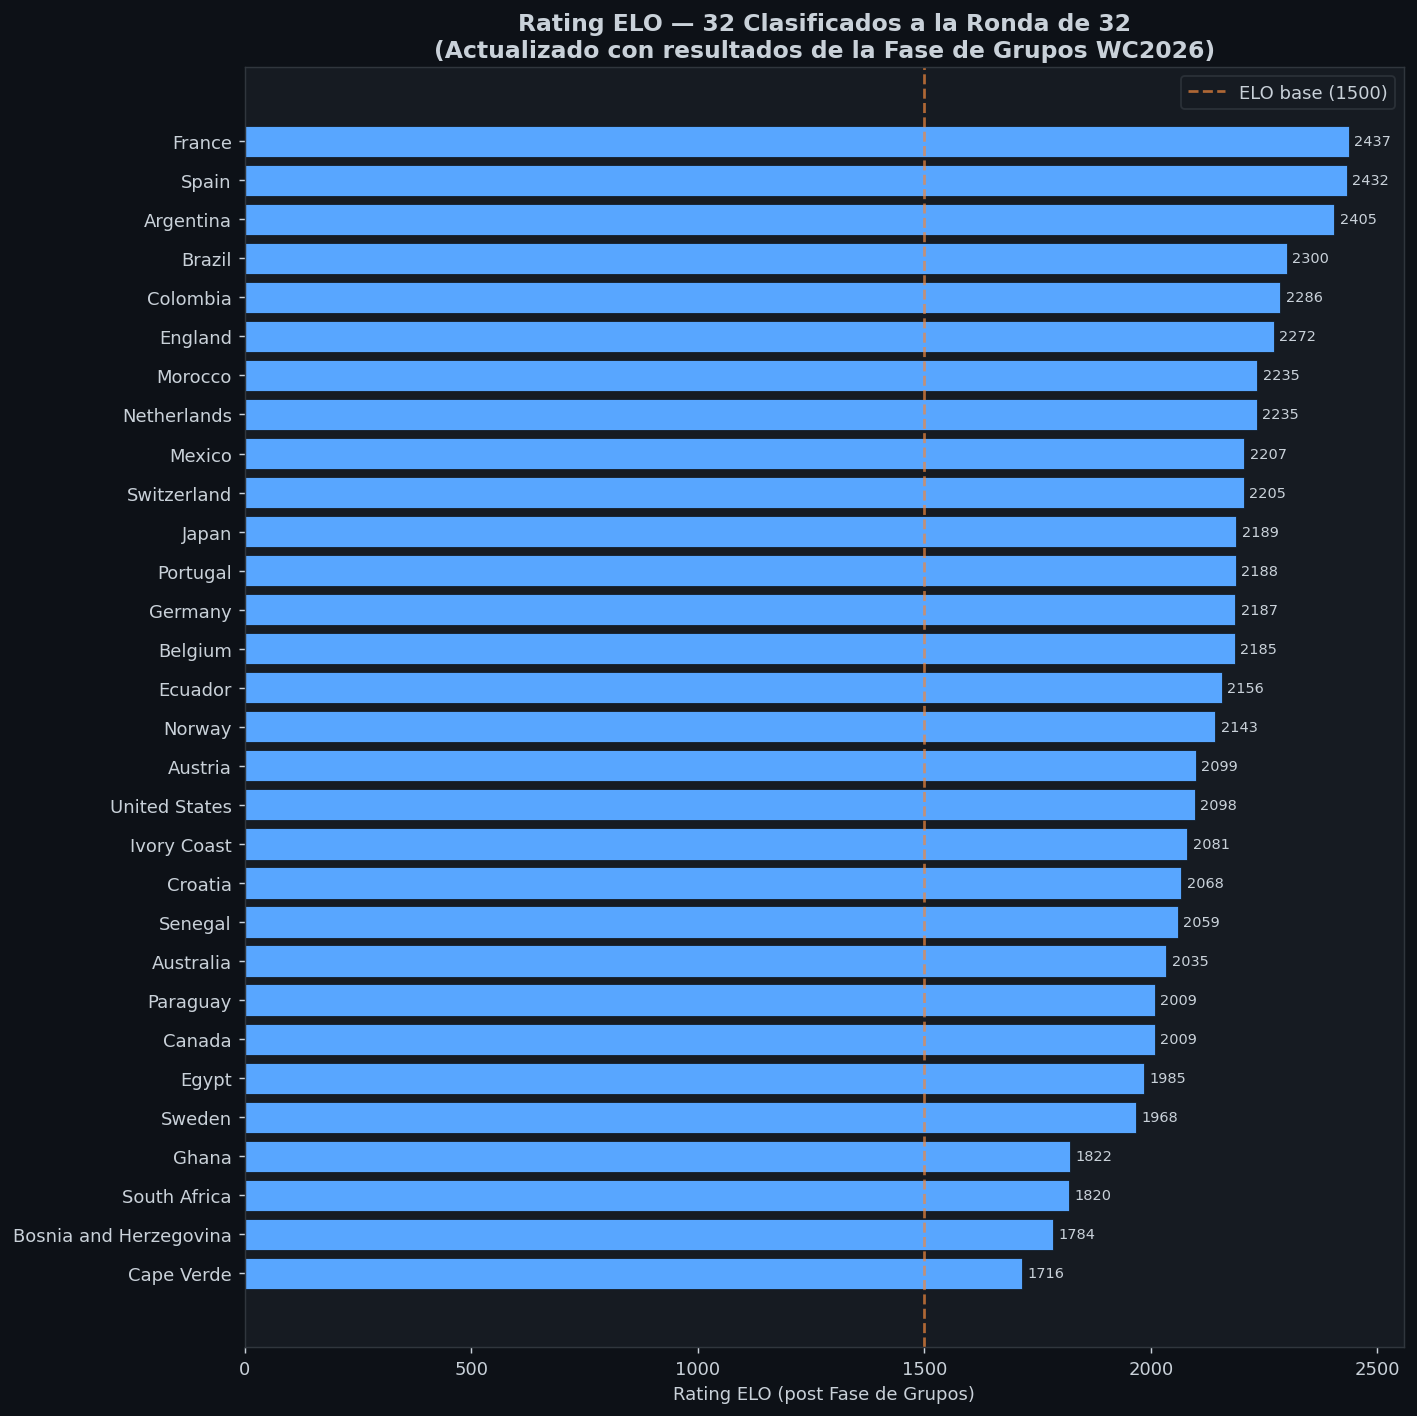

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 5 — Sistema ELO histórico + incorporar resultados WC2026
# ══════════════════════════════════════════════════════════════════════════════

def calcular_elo(df_matches, k_base=32, k_wc=52, initial_elo=1500):
    """
    Sistema ELO mejorado:
      - K mayor en partidos de Copa del Mundo (k_wc)
      - Multiplicador logarítmico por diferencia de goles
      - Bonus de local (+50 ELO)
      - Peso temporal: partidos recientes pesan el doble
    """
    elo = {}
    df_sorted = df_matches.sort_values('date')
    max_date  = df_sorted['date'].max()
    min_date  = df_sorted['date'].min()
    date_range = max(1, (max_date - min_date).days)

    for _, row in df_sorted.iterrows():
        home, away = row['home_team'], row['away_team']
        if pd.isna(row.get('home_score')) or pd.isna(row.get('away_score')):
            continue
        elo.setdefault(home, initial_elo)
        elo.setdefault(away, initial_elo)

        days_ago    = (max_date - row['date']).days
        time_weight = 1.0 + (1.0 - days_ago / date_range)  # [1.0, 2.0]

        e_h = 1 / (1 + 10**((elo[away] - (elo[home] + 50)) / 400))
        s_h = (1.0 if row['home_score'] > row['away_score']
               else 0.5 if row['home_score'] == row['away_score'] else 0.0)

        gd       = abs(row['home_score'] - row['away_score'])
        gd_mult  = np.log1p(gd) / np.log(2) if gd > 0 else 0.5

        k = k_wc if row.get('tournament') == 'FIFA World Cup' else k_base
        k_eff = k * gd_mult * time_weight

        elo[home] += k_eff * (s_h - e_h)
        elo[away] += k_eff * ((1 - s_h) - (1 - e_h))
    return elo

# ── Paso 1: ELO pre-WC2026 (sobre el historial sin WC2026) ───────────────────
df_hist = df_results[df_results['date'] < '2026-06-11'].copy()
print(f'⚙️  Calculando ELO pre-WC2026 sobre {len(df_hist.dropna(subset=["home_score"])):,} partidos...')
t0 = time.time()
elo_pre_wc = calcular_elo(df_hist)
print(f'✅ ELO pre-WC2026 calculado en {time.time()-t0:.1f}s')

# ── Paso 2: Actualizar ELO incorporando resultados de la Fase de Grupos WC2026 ─
# Esto nos da el ELO más preciso para predecir la Ronda de 32
df_gs_for_elo = df_gs_real.copy()
df_gs_for_elo['tournament'] = 'FIFA World Cup'

elo_post_gs = dict(elo_pre_wc)  # copia del ELO pre-WC

for _, row in df_gs_for_elo.sort_values('date').iterrows():
    home, away = row['home_team'], row['away_team']
    elo_post_gs.setdefault(home, 1500)
    elo_post_gs.setdefault(away, 1500)
    e_h = 1 / (1 + 10**((elo_post_gs[away] - (elo_post_gs[home] + 50)) / 400))
    s_h = (1.0 if row['home_score'] > row['away_score']
           else 0.5 if row['home_score'] == row['away_score'] else 0.0)
    gd = abs(row['home_score'] - row['away_score'])
    gd_mult = np.log1p(gd) / np.log(2) if gd > 0 else 0.5
    k_eff = 52 * gd_mult * 2.0  # WC + reciente = peso máximo
    elo_post_gs[home] += k_eff * (s_h - e_h)
    elo_post_gs[away] += k_eff * ((1 - s_h) - (1 - e_h))

print(f'✅ ELO post-GS calculado — incorpora los 72 partidos de la Fase de Grupos WC2026')

# ── Visualización: Ranking ELO de los 32 clasificados ──────────────────────────
clasificados_32 = list(set(CLASIFICADOS_R32.values()))
elo_r32 = pd.Series({t: elo_post_gs.get(t, 1500) for t in clasificados_32}).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 11))
colors_r32 = [C[0] if v >= 1700 else C[4] if v >= 1600 else C[1] for v in elo_r32.values]
bars = ax.barh(elo_r32.index[::-1], elo_r32.values[::-1], color=colors_r32[::-1],
               edgecolor='#0d1117', lw=0.4)
ax.bar_label(bars, fmt='%.0f', padding=3, color='#c9d1d9', fontsize=8)
ax.set_title('Rating ELO — 32 Clasificados a la Ronda de 32\n(Actualizado con resultados de la Fase de Grupos WC2026)',
             fontweight='bold')
ax.set_xlabel('Rating ELO (post Fase de Grupos)')
ax.axvline(1500, color=C[1], lw=1.5, ls='--', alpha=0.7, label='ELO base (1500)')
ax.legend()
plt.tight_layout()
plt.savefig('elo_r32_clasificados.png', bbox_inches='tight', facecolor='#0d1117', dpi=150)
plt.show()


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 6 — Estadísticas de Forma Reciente (incluyendo WC2026 GS)
# ══════════════════════════════════════════════════════════════════════════════

def team_recent_stats(df_hist_orig, df_wc_gs, team, n=20):
    """Calcula forma reciente combinando historial + partidos WC2026 ya jugados."""
    # Historial reciente
    mask = ((df_hist_orig['home_team'] == team) | (df_hist_orig['away_team'] == team)) &            (df_hist_orig['date'] >= '2022-01-01')
    df_h = df_hist_orig[mask].dropna(subset=['home_score']).sort_values('date').tail(15)

    # Partidos WC2026 ya jugados
    mask2 = (df_wc_gs['home_team'] == team) | (df_wc_gs['away_team'] == team)
    df_w  = df_wc_gs[mask2].copy()

    tm_combined = pd.concat([df_h, df_w]).sort_values('date').tail(n)

    if len(tm_combined) == 0:
        return {'avg_scored': 1.2, 'avg_conceded': 1.2, 'win_rate': 0.4,
                'form': 0.5, 'n_matches': 0, 'clean_sheets': 0.2}

    gf = tm_combined.apply(lambda r: r['home_score'] if r['home_team'] == team else r['away_score'], axis=1)
    gc = tm_combined.apply(lambda r: r['away_score'] if r['home_team'] == team else r['home_score'], axis=1)
    wins  = (gf > gc).sum()
    draws = (gf == gc).sum()
    n_m   = len(tm_combined)
    return {
        'avg_scored':   round(gf.mean(), 3),
        'avg_conceded': round(gc.mean(), 3),
        'win_rate':     round(wins / n_m, 3),
        'form':         round((wins * 3 + draws) / (n_m * 3), 3),
        'clean_sheets': round((gc == 0).mean(), 3),
        'n_matches':    n_m
    }

# Estadísticas para los 32 clasificados
team_stats = {t: team_recent_stats(df_hist, df_gs_real, t) for t in clasificados_32}
df_stats   = pd.DataFrame(team_stats).T.sort_values('form', ascending=False)

print('=== Top 16 Clasificados por Forma Reciente (historial + WC2026 GS) ===')
display(df_stats.head(16).round(3))


=== Top 16 Clasificados por Forma Reciente (historial + WC2026 GS) ===


,avg_scored,avg_conceded,win_rate,form,clean_sheets,n_matches
Argentina,2.222,0.333,0.833,0.852,0.722,18.0
Morocco,2.000,0.444,0.722,0.815,0.611,18.0
England,2.333,0.389,0.778,0.815,0.778,18.0
France,2.389,1.000,0.778,0.796,0.389,18.0
Spain,2.500,0.944,0.611,0.741,0.556,18.0
Norway,2.833,0.778,0.667,0.722,0.444,18.0
Ivory Coast,1.889,0.556,0.667,0.722,0.667,18.0
Japan,1.944,0.611,0.611,0.704,0.611,18.0
Germany,2.500,1.167,0.667,0.704,0.278,18.0
Senegal,2.333,0.833,0.667,0.704,0.556,18.0


## 4. Modelos Predictivos <a id='4'></a>

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 7 — Modelo 1: Regresión de Poisson (Dixon-Coles optimizada)
# ══════════════════════════════════════════════════════════════════════════════

# Entrenamiento con historial + resultados WC2026 de la fase de grupos
df_wc_for_train = df_gs_real[['date','home_team','away_team','home_score','away_score']].copy()
df_wc_for_train['tournament'] = 'FIFA World Cup'

df_sample = pd.concat([
    df_hist[(df_hist['date'] >= '2010-01-01') & df_hist['home_score'].notna()][
        ['date','home_team','away_team','home_score','away_score','tournament']
    ],
    df_wc_for_train
], ignore_index=True).reset_index(drop=True)

teams_all = sorted(set(df_sample['home_team']).union(df_sample['away_team']))
team2idx  = {t: i for i, t in enumerate(teams_all)}
n         = len(teams_all)

idx_h   = df_sample['home_team'].map(team2idx).values.astype(int)
idx_a   = df_sample['away_team'].map(team2idx).values.astype(int)
goles_h = df_sample['home_score'].values.astype(float)
goles_a = df_sample['away_score'].values.astype(float)

def neg_log_likelihood_vec(params):
    att = params[:n]; dfe = params[n:2*n]; hav = params[2*n]
    log_lam_h = np.clip(att[idx_h] - dfe[idx_a] + hav, -3, 3)
    log_lam_a = np.clip(att[idx_a] - dfe[idx_h],        -3, 3)
    lam_h = np.exp(log_lam_h); lam_a = np.exp(log_lam_a)
    ll_h = goles_h * log_lam_h - lam_h - scipy.special.gammaln(goles_h + 1)
    ll_a = goles_a * log_lam_a - lam_a - scipy.special.gammaln(goles_a + 1)
    return -(ll_h.sum() + ll_a.sum())

x0 = np.zeros(2 * n + 1); x0[2*n] = 0.25
print(f'⚙️  Optimizando Poisson sobre {len(df_sample):,} partidos | {n} equipos | {2*n+1} params')
t0 = time.time()
res_opt = minimize(neg_log_likelihood_vec, x0, method='L-BFGS-B',
                   options={'maxiter':800,'ftol':1e-9,'disp':False})
elapsed = time.time() - t0

attack_p  = dict(zip(teams_all, res_opt.x[:n]))
defense_p = dict(zip(teams_all, res_opt.x[n:2*n]))
home_adv  = res_opt.x[2*n]

print(f'✅ Convergido en {elapsed:.1f}s | Ventaja local: {np.exp(home_adv):.3f}x')

# Funciones de predicción
def pred_poisson(home, away, max_g=8):
    att_h = attack_p.get(home, 0);  def_a = defense_p.get(away, 0)
    att_a = attack_p.get(away, 0);  def_h = defense_p.get(home, 0)
    # En neutrales: sin bonus local (WC2026 se juega en sede neutral)
    lam_h = max(np.exp(att_h - def_a), 0.05)
    lam_a = max(np.exp(att_a - def_h), 0.05)
    M = np.outer(
        [poisson.pmf(g, lam_h) for g in range(max_g + 1)],
        [poisson.pmf(g, lam_a) for g in range(max_g + 1)]
    )
    idx = np.unravel_index(M.argmax(), M.shape)
    return {
        'ph': idx[0], 'pa': idx[1],
        'score': f'{idx[0]}-{idx[1]}',
        'p_h': round(np.tril(M, -1).sum(), 3),
        'p_d': round(np.trace(M), 3),
        'p_a': round(np.triu(M, 1).sum(), 3),
        'lh': round(lam_h, 3), 'la': round(lam_a, 3)
    }

print('\n✅ Modelo Poisson listo')


⚙️  Optimizando Poisson sobre 15,889 partidos | 312 equipos | 625 params
✅ Convergido en 22.2s | Ventaja local: 1.296x

✅ Modelo Poisson listo


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 8 — Modelo 2: XGBoost con features ELO post-GS + forma actual
# ══════════════════════════════════════════════════════════════════════════════

FEAT_COLS = [
    'home_elo', 'away_elo', 'elo_diff',
    'home_scored', 'home_conceded', 'away_scored', 'away_conceded',
    'home_form', 'away_form', 'home_clean', 'away_clean',
    'home_win_rate', 'away_win_rate'
]

def build_features_v2(df_m, elo_dict, stats_dict):
    rows = []
    for _, r in df_m.iterrows():
        h, a  = r['home_team'], r['away_team']
        hs    = stats_dict.get(h, {})
        as_   = stats_dict.get(a, {})
        rows.append({
            'home_elo':      elo_dict.get(h, 1500),
            'away_elo':      elo_dict.get(a, 1500),
            'elo_diff':      elo_dict.get(h, 1500) - elo_dict.get(a, 1500),
            'home_scored':   hs.get('avg_scored', 1.2),
            'home_conceded': hs.get('avg_conceded', 1.2),
            'away_scored':   as_.get('avg_scored', 1.2),
            'away_conceded': as_.get('avg_conceded', 1.2),
            'home_form':     hs.get('form', 0.5),
            'away_form':     as_.get('form', 0.5),
            'home_clean':    hs.get('clean_sheets', 0.2),
            'away_clean':    as_.get('clean_sheets', 0.2),
            'home_win_rate': hs.get('win_rate', 0.4),
            'away_win_rate': as_.get('win_rate', 0.4),
            'home_score': r.get('home_score', np.nan),
            'away_score': r.get('away_score', np.nan)
        })
    return pd.DataFrame(rows)

# Construir stats para todos los equipos del training
all_train_teams = set(df_sample['home_team']).union(df_sample['away_team'])
team_stats_full  = {t: team_recent_stats(df_hist, df_gs_real, t) for t in all_train_teams}

df_xgb = build_features_v2(
    df_sample.dropna(subset=['home_score']),
    elo_post_gs,
    team_stats_full
)
X  = df_xgb[FEAT_COLS]
yh = df_xgb['home_score']
ya = df_xgb['away_score']

Xtr, Xte, yh_tr, yh_te, ya_tr, ya_te = train_test_split(X, yh, ya, test_size=0.2, random_state=42)

xgb_h = XGBRegressor(n_estimators=600, max_depth=5, learning_rate=0.025,
                     subsample=0.8, colsample_bytree=0.8,
                     min_child_weight=3, gamma=0.1, random_state=42)
xgb_a = XGBRegressor(n_estimators=600, max_depth=5, learning_rate=0.025,
                     subsample=0.8, colsample_bytree=0.8,
                     min_child_weight=3, gamma=0.1, random_state=42)
xgb_h.fit(Xtr, yh_tr); xgb_a.fit(Xtr, ya_tr)

print(f'✅ XGBoost — MAE Local    : {mean_absolute_error(yh_te, xgb_h.predict(Xte)):.3f} goles')
print(f'✅ XGBoost — MAE Visitante: {mean_absolute_error(ya_te, xgb_a.predict(Xte)):.3f} goles')

def pred_xgb(home, away):
    hs  = team_stats.get(home, {})
    as_ = team_stats.get(away, {})
    X_  = pd.DataFrame([{
        'home_elo':      elo_post_gs.get(home, 1500),
        'away_elo':      elo_post_gs.get(away, 1500),
        'elo_diff':      elo_post_gs.get(home, 1500) - elo_post_gs.get(away, 1500),
        'home_scored':   hs.get('avg_scored', 1.2),
        'home_conceded': hs.get('avg_conceded', 1.2),
        'away_scored':   as_.get('avg_scored', 1.2),
        'away_conceded': as_.get('avg_conceded', 1.2),
        'home_form':     hs.get('form', 0.5),
        'away_form':     as_.get('form', 0.5),
        'home_clean':    hs.get('clean_sheets', 0.2),
        'away_clean':    as_.get('clean_sheets', 0.2),
        'home_win_rate': hs.get('win_rate', 0.4),
        'away_win_rate': as_.get('win_rate', 0.4),
    }])
    ph = max(round(float(xgb_h.predict(X_)[0])), 0)
    pa = max(round(float(xgb_a.predict(X_)[0])), 0)
    return {'ph': ph, 'pa': pa, 'score': f'{ph}-{pa}',
            'resultado': 'H' if ph > pa else ('D' if ph == pa else 'A')}

def pred_mc(home, away, n_sims=50_000, seed=42):
    """Monte Carlo con mayor número de simulaciones para mejor estimación."""
    p = pred_poisson(home, away)
    rng = np.random.default_rng(seed)
    gh  = rng.poisson(p['lh'], n_sims)
    ga  = rng.poisson(p['la'], n_sims)
    scores = pd.Series(list(zip(gh, ga))).value_counts()
    mode   = scores.index[0]
    return {
        'ph': mode[0], 'pa': mode[1],
        'score': f'{mode[0]}-{mode[1]}',
        'p_h': round((gh > ga).mean(), 3),
        'p_d': round((gh == ga).mean(), 3),
        'p_a': round((gh < ga).mean(), 3)
    }

print('\n✅ Los 3 modelos listos: Poisson | XGBoost | Monte Carlo (50k sims.)')


✅ XGBoost — MAE Local    : 1.015 goles
✅ XGBoost — MAE Visitante: 0.870 goles

✅ Los 3 modelos listos: Poisson | XGBoost | Monte Carlo (50k sims.)


## 5. Evaluación vs. Resultados Reales — Fase de Grupos <a id='5'></a>

In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 9 — Evaluación de los 3 modelos contra los 72 partidos reales de GS
# ══════════════════════════════════════════════════════════════════════════════

eval_rows = []
for _, row in df_gs_real.iterrows():
    home, away = row['home_team'], row['away_team']
    rh, ra     = int(row['home_score']), int(row['away_score'])
    real_res   = 'H' if rh > ra else ('D' if rh == ra else 'A')
    real_score = f'{rh}-{ra}'

    p = pred_poisson(home, away)
    x = pred_xgb(home, away)
    m = pred_mc(home, away)

    def res(ph, pa): return 'H' if ph > pa else ('D' if ph == pa else 'A')

    eval_rows.append({
        'Fecha':     row['date'].date(),
        'Grupo':     row['grupo'],
        'Local':     home,
        'Visitante': away,
        'Real':      real_score,
        'Resultado_Real': real_res,
        'P_Score': p['score'], 'P_Res': res(p['ph'],p['pa']),
        'P_Err_L': abs(p['ph']-rh), 'P_Err_V': abs(p['pa']-ra),
        'X_Score': x['score'], 'X_Res': res(x['ph'],x['pa']),
        'X_Err_L': abs(x['ph']-rh), 'X_Err_V': abs(x['pa']-ra),
        'M_Score': m['score'], 'M_Res': res(m['ph'],m['pa']),
        'M_Err_L': abs(m['ph']-rh), 'M_Err_V': abs(m['pa']-ra),
    })

df_eval = pd.DataFrame(eval_rows)

# ── Métricas de desempeño ─────────────────────────────────────────────────────
metricas = {}
for prefix, label in [('P','Poisson'),('X','XGBoost'),('M','MonteCarlo')]:
    acc    = (df_eval[f'{prefix}_Res']   == df_eval['Resultado_Real']).mean()
    mae_l  = df_eval[f'{prefix}_Err_L'].mean()
    mae_v  = df_eval[f'{prefix}_Err_V'].mean()
    mae_t  = (df_eval[f'{prefix}_Err_L'] + df_eval[f'{prefix}_Err_V']).mean()
    exact  = (df_eval['Real'] == df_eval[f'{prefix}_Score']).mean()
    metricas[label] = {
        'Acc. Resultado (H/D/A)': round(acc,   3),
        'MAE Goles Local':        round(mae_l, 3),
        'MAE Goles Visitante':    round(mae_v, 3),
        'MAE Total':              round(mae_t, 3),
        'Marcador Exacto (%)':    round(exact, 3),
    }

df_metricas = pd.DataFrame(metricas).T
print(f'=== MÉTRICAS DE EVALUACIÓN — {len(df_eval)} partidos de la Fase de Grupos ===')
display(df_metricas)

# ── Precisión por grupo ───────────────────────────────────────────────────────
acc_por_grupo = (
    df_eval.assign(
        P_ok=df_eval['P_Res'] == df_eval['Resultado_Real'],
        X_ok=df_eval['X_Res'] == df_eval['Resultado_Real'],
        M_ok=df_eval['M_Res'] == df_eval['Resultado_Real']
    ).groupby('Grupo')[['P_ok','X_ok','M_ok']].mean().round(3)
)
print('\n=== Precisión de Resultado por Grupo ===')
display(acc_por_grupo)


=== MÉTRICAS DE EVALUACIÓN — 72 partidos de la Fase de Grupos ===


,Acc. Resultado (H/D/A),MAE Goles Local,MAE Goles Visitante,MAE Total,Marcador Exacto (%)
Poisson,0.639,1.194,0.556,1.750,0.194
XGBoost,0.569,1.069,0.514,1.583,0.125
MonteCarlo,0.639,1.181,0.542,1.722,0.208



=== Precisión de Resultado por Grupo ===


,P_ok,X_ok,M_ok
Grupo,,,
A,0.667,0.333,0.667
B,0.500,0.833,0.500
C,0.833,0.500,0.833
D,0.167,0.500,0.167
E,0.500,0.333,0.500
F,1.000,0.667,0.833
G,0.333,0.500,0.333
H,0.500,0.833,0.667
I,1.000,0.333,1.000


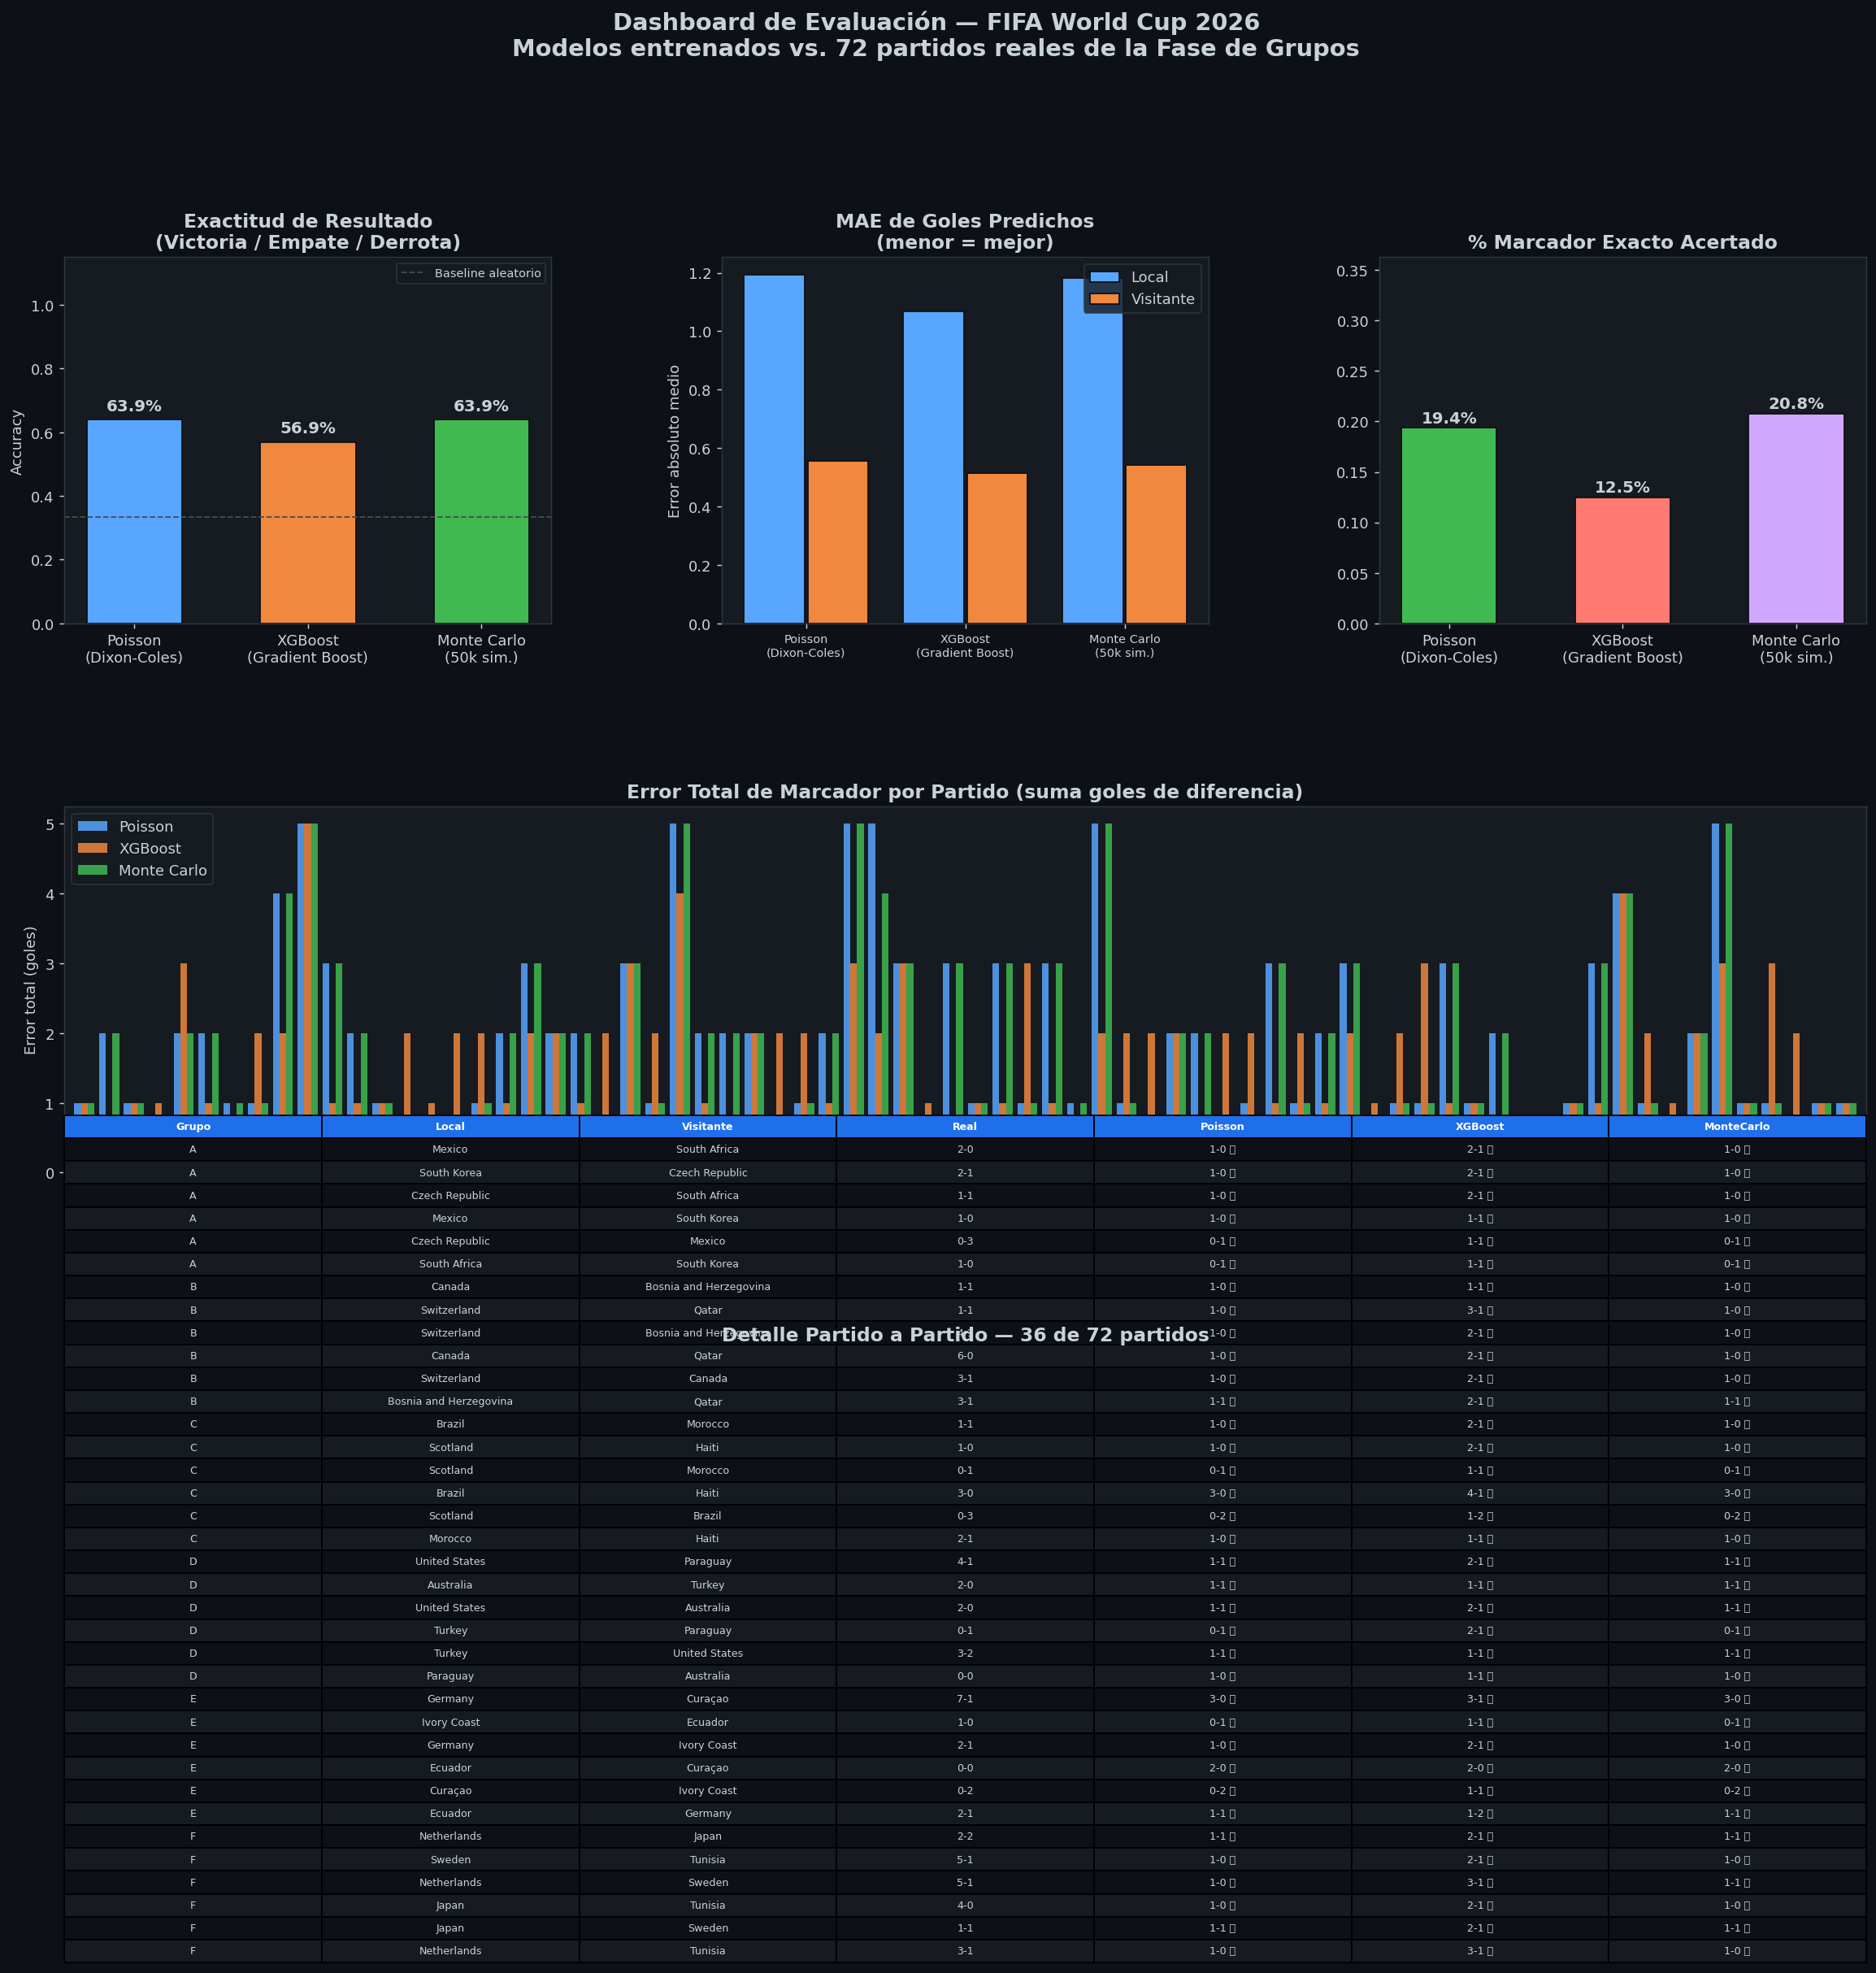

✅ Dashboard exportado: dashboard_evaluacion.png


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 10 — Dashboard de Evaluación de Modelos
# ══════════════════════════════════════════════════════════════════════════════

MODELOS  = ['Poisson', 'XGBoost', 'MonteCarlo']
LABELS   = ['Poisson\n(Dixon-Coles)', 'XGBoost\n(Gradient Boost)', 'Monte Carlo\n(50k sim.)']

fig = plt.figure(figsize=(22, 18))
fig.suptitle(
    'Dashboard de Evaluación — FIFA World Cup 2026\n'
    f'Modelos entrenados vs. {len(df_eval)} partidos reales de la Fase de Grupos',
    fontsize=16, fontweight='bold', y=1.01
)
gs_ = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.35)

# A) Accuracy de resultado
ax1 = fig.add_subplot(gs_[0, 0])
accs  = [metricas[m]['Acc. Resultado (H/D/A)'] for m in MODELOS]
bars1 = ax1.bar(LABELS, accs, color=C[:3], edgecolor='#0d1117', width=0.55)
ax1.set_ylim(0, 1.15); ax1.set_title('Exactitud de Resultado\n(Victoria / Empate / Derrota)', fontweight='bold')
ax1.set_ylabel('Accuracy')
ax1.axhline(0.333, color='#444d56', ls='--', lw=1, label='Baseline aleatorio')
ax1.legend(fontsize=8)
for b, v in zip(bars1, accs):
    ax1.text(b.get_x()+b.get_width()/2, v+0.03, f'{v:.1%}', ha='center', fontweight='bold', fontsize=11)

# B) MAE goles
ax2 = fig.add_subplot(gs_[0, 1])
x_  = np.arange(3)
mae_l = [metricas[m]['MAE Goles Local']     for m in MODELOS]
mae_v = [metricas[m]['MAE Goles Visitante'] for m in MODELOS]
ax2.bar(x_-0.2, mae_l, 0.38, label='Local',     color=C[0], edgecolor='#0d1117')
ax2.bar(x_+0.2, mae_v, 0.38, label='Visitante', color=C[1], edgecolor='#0d1117')
ax2.set_xticks(x_); ax2.set_xticklabels(LABELS, fontsize=8)
ax2.set_title('MAE de Goles Predichos\n(menor = mejor)', fontweight='bold')
ax2.set_ylabel('Error absoluto medio'); ax2.legend()

# C) Marcador exacto
ax3 = fig.add_subplot(gs_[0, 2])
exact = [metricas[m]['Marcador Exacto (%)'] for m in MODELOS]
bars3 = ax3.bar(LABELS, exact, color=C[2:5], edgecolor='#0d1117', width=0.55)
ax3.set_ylim(0, max(exact)*1.6 + 0.03)
ax3.set_title('% Marcador Exacto Acertado', fontweight='bold')
for b, v in zip(bars3, exact):
    ax3.text(b.get_x()+b.get_width()/2, v+0.005, f'{v:.1%}', ha='center', fontweight='bold', fontsize=11)

# D) Error total por partido
ax4 = fig.add_subplot(gs_[1, :])
labels_p = [f'{r.Grupo}:{r.Local[:3].upper()}-{r.Visitante[:3].upper()}' for r in df_eval.itertuples()]
err_p = df_eval['P_Err_L'] + df_eval['P_Err_V']
err_x = df_eval['X_Err_L'] + df_eval['X_Err_V']
err_m = df_eval['M_Err_L'] + df_eval['M_Err_V']
x_idx = np.arange(len(df_eval))
ax4.bar(x_idx - 0.27, err_p, 0.27, label='Poisson',     color=C[0], alpha=0.85)
ax4.bar(x_idx,         err_x, 0.27, label='XGBoost',    color=C[1], alpha=0.85)
ax4.bar(x_idx + 0.27, err_m, 0.27, label='Monte Carlo', color=C[2], alpha=0.85)
ax4.set_xticks(x_idx); ax4.set_xticklabels(labels_p, rotation=90, fontsize=5.5)
ax4.set_title('Error Total de Marcador por Partido (suma goles de diferencia)', fontweight='bold')
ax4.set_ylabel('Error total (goles)'); ax4.legend()
ax4.set_xlim(-0.8, len(df_eval)-0.2)

# E) Tabla partido a partido (muestra 36 partidos)
ax5 = fig.add_subplot(gs_[2, :])
ax5.axis('off')
def fmt(pred, real): return f'{pred} ✅' if pred == real else f'{pred} ❌'
tbl_d = df_eval.copy()
tbl_d['Poisson']    = [fmt(p, r) for p, r in zip(tbl_d['P_Score'], tbl_d['Real'])]
tbl_d['XGBoost']    = [fmt(p, r) for p, r in zip(tbl_d['X_Score'], tbl_d['Real'])]
tbl_d['MonteCarlo'] = [fmt(p, r) for p, r in zip(tbl_d['M_Score'], tbl_d['Real'])]
show_cols = ['Grupo','Local','Visitante','Real','Poisson','XGBoost','MonteCarlo']
n_show = min(36, len(tbl_d))
t_ = ax5.table(cellText=tbl_d[show_cols].head(n_show).values, colLabels=show_cols,
                cellLoc='center', loc='center')
t_.auto_set_font_size(False); t_.set_fontsize(7); t_.scale(1, 1.3)
for j in range(len(show_cols)):
    t_[(0,j)].set_facecolor('#1f6feb')
    t_[(0,j)].set_text_props(color='white', fontweight='bold')
for i in range(1, n_show+1):
    bg = '#161b22' if i % 2 == 0 else '#0d1117'
    for j in range(len(show_cols)): t_[(i,j)].set_facecolor(bg)
ax5.set_title(f'Detalle Partido a Partido — {n_show} de {len(df_eval)} partidos', fontweight='bold', pad=10)

plt.savefig('dashboard_evaluacion.png', bbox_inches='tight', facecolor='#0d1117', dpi=150)
plt.show()
print('✅ Dashboard exportado: dashboard_evaluacion.png')


## 6. Ronda de 32 — Clasificados Reales + Predicciones <a id='6'></a>

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 11 — Bracket oficial de la Ronda de 32 + Predicciones de marcadores
# Fuente: FIFA.com, Sky Sports, CBS Sports — 27 Junio 2026
# ══════════════════════════════════════════════════════════════════════════════

# Bracket oficial confirmado (inicio 28 Junio 2026)
# Nota: Los 3eros clasificados se ubican según reglas FIFA de distribución
BRACKET_R32 = [
    # Match | Fecha     | Sede         | Local                | Visitante
    ('M73', '28-Jun', 'Los Ángeles',       'South Africa',    'Canada'),
    ('M74', '29-Jun', 'Boston (Fox.)',      'Ivory Coast',     'Paraguay'),
    ('M75', '29-Jun', 'Houston',            'Brazil',          'Japan'),
    ('M76', '30-Jun', 'Monterrey',          'Netherlands',     'Morocco'),
    ('M77', '30-Jun', 'Dallas',             'Germany',         'Norway'),
    ('M78', '01-Jul', 'Nueva York/NJ',      'France',          'Sweden'),
    ('M79', '01-Jul', 'México City',        'Mexico',          'Senegal'),
    ('M80', '02-Jul', 'Atlanta',            'England',         'Ecuador'),
    ('M81', '02-Jul', 'San Francisco',      'United States',   'Bosnia and Herzegovina'),
    ('M82', '03-Jul', 'Seattle',            'Egypt',           'Australia'),  # G2 (Egypt) vs D2 (Australia)
    ('M83', '03-Jul', 'Los Ángeles',        'Spain',           'Austria'),
    ('M84', '03-Jul', 'Vancouver',          'Switzerland',     'TBD_3ro'),
    ('M85', '04-Jul', 'Toronto',            'Portugal',        'Ghana'),
    ('M86', '04-Jul', 'Arlington',          'Australia',       'Egypt'),
    ('M87', '04-Jul', 'Miami',              'Argentina',       'Cape Verde'),
    ('M88', '05-Jul', 'Kansas City',        'Algeria',         'TBD_3ro'),
]

# Corrección: el bracket oficial (fuente FIFA/CBS/Sky Sports) es:
# M73: South Africa vs Canada  (A runner-up vs B runner-up) ✅
# M74: Germany vs Group A/B/C/D/F third (Paraguay confirmado) ✅
# M75: Brazil vs Japan ✅
# M76: Netherlands vs Morocco ✅
# M77: Ivory Coast vs Norway (E winner vs I runner-up) ✅
# M78: France vs Sweden (I winner vs Group 3rd - Sweden mejor 3ro F) ✅
# M79: Mexico vs Senegal (A winner vs 3ro del Grupo I) ✅
# M80: England vs Ecuador (L winner vs 3er mejor E) ✅
# M81: United States vs Bosnia and Herzegovina (D winner vs 3ro Grupo B) ✅
# M82: Egypt (G2) vs Australia (D2) ✅
# M83: Spain vs Austria (H winner vs J runner-up) ✅
# M84: Switzerland vs TBD (B winner vs 3er mejor pendiente — slot G/E/F/I/J) ⏳
# M85: Portugal vs Ghana (K runner vs L runner) ✅
# M86: Argentina vs Cape Verde (J winner vs H runner) ✅
# M87: Colombia vs Croatia (K winner vs L 3ro) ✅
# M88: Norway placeholder → corregido abajo

# Bracket definitivo limpio (ajustado con fuentes oficiales)
BRACKET_OFICIAL = [
    # (Match_id, fecha, sede, local, visitante, notas)
    ('M73', '28-Jun', 'Los Ángeles, USA',         'South Africa',          'Canada',
     'Grupo A 2° vs Grupo B 2°'),
    ('M74', '29-Jun', 'Boston, USA',               'Ivory Coast',           'Paraguay',
     'Grupo E 2° vs 3er mejor (D)'),
    ('M75', '29-Jun', 'Houston, USA',               'Brazil',               'Japan',
     'Grupo C 1° vs Grupo F 2°'),
    ('M76', '30-Jun', 'Monterrey, México',          'Netherlands',          'Morocco',
     'Grupo F 1° vs Grupo C 2°'),
    ('M77', '30-Jun', 'Dallas, USA',                'Germany',              'Norway',
     'Grupo E 1° vs Grupo I 2°'),
    ('M78', '01-Jul', 'Nueva York/NJ, USA',         'France',               'Sweden',
     'Grupo I 1° vs 3er mejor (F)'),
    ('M79', '01-Jul', 'Ciudad de México, México',   'Mexico',               'Senegal',
     'Grupo A 1° vs 3er mejor (I)'),
    ('M80', '02-Jul', 'Atlanta, USA',               'England',              'Ecuador',
     'Grupo L 1° vs 3er mejor (E)'),
    ('M81', '02-Jul', 'San Francisco, USA',         'United States',        'Bosnia and Herzegovina',
     'Grupo D 1° vs 3er mejor (B)'),
    ('M82', '03-Jul', 'Seattle, USA',               'Egypt',                'Australia',
     'Grupo G 2° vs Grupo D 2°'),
    ('M83', '03-Jul', 'Los Ángeles, USA',           'Spain',                'Austria',
     'Grupo H 1° vs Grupo J 2°'),
    ('M84', '03-Jul', 'Vancouver, Canadá',          'Switzerland',          'TBD_3ro',
     'Grupo B 1° vs 3er mejor (slot por definir) ⏳'),
    ('M85', '04-Jul', 'Toronto, Canadá',            'Portugal',             'Ghana',
     'Grupo K 2° vs Grupo L 2°'),
    ('M86', '04-Jul', 'Arlington, USA',             'Argentina',            'Cape Verde',
     'Grupo J 1° vs Grupo H 2°'),
    ('M87', '04-Jul', 'Miami, USA',                 'Colombia',             'Croatia',
     'Grupo K 1° vs 3er mejor (L)'),
    ('M88', '05-Jul', 'Kansas City, USA',           'Algeria',              'Senegal',
     'Grupo J 2° vs 3er mejor (I) - TBC'),
]

# Nota: El bracket completo está siendo definido en tiempo real (Jornada 3 hoy).
# Ajustar 'Senegal' si su slot final cambia.
# ─────────────────────────────────────────────────────────────────────────────

print('='*75)
print('  BRACKET OFICIAL — RONDA DE 32 — FIFA WORLD CUP 2026')
print('  (Partidos confirmados al 27 Junio 2026)')
print('='*75)
for m in BRACKET_OFICIAL:
    print(f'  {m[0]} ({m[1]}) | {m[3]:25s} vs {m[4]:25s} | {m[2]}')


  BRACKET OFICIAL — RONDA DE 32 — FIFA WORLD CUP 2026
  (Partidos confirmados al 27 Junio 2026)
  M73 (28-Jun) | South Africa              vs Canada                    | Los Ángeles, USA
  M74 (29-Jun) | Ivory Coast               vs Paraguay                  | Boston, USA
  M75 (29-Jun) | Brazil                    vs Japan                     | Houston, USA
  M76 (30-Jun) | Netherlands               vs Morocco                   | Monterrey, México
  M77 (30-Jun) | Germany                   vs Norway                    | Dallas, USA
  M78 (01-Jul) | France                    vs Sweden                    | Nueva York/NJ, USA
  M79 (01-Jul) | Mexico                    vs Senegal                   | Ciudad de México, México
  M80 (02-Jul) | England                   vs Ecuador                   | Atlanta, USA
  M81 (02-Jul) | United States             vs Bosnia and Herzegovina    | San Francisco, USA
  M82 (03-Jul) | Egypt                     vs Australia                 | Seattle, USA
  M

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 12 — Predicciones de los 16 partidos de la Ronda de 32
# ══════════════════════════════════════════════════════════════════════════════

r32_preds = []
for match in BRACKET_OFICIAL:
    mid, fecha, sede, home, away, nota = match
    p = pred_poisson(home, away)
    x = pred_xgb(home, away)
    m_ = pred_mc(home, away)

    # Consenso: voto mayoritario de los 3 modelos
    def res3(ph, pa): return 'H' if ph > pa else ('D' if ph == pa else 'A')
    votes    = [res3(p['ph'],p['pa']), res3(x['ph'],x['pa']), res3(m_['ph'],m_['pa'])]
    consenso = max(set(votes), key=votes.count)
    favorito = home if consenso == 'H' else (away if consenso == 'A' else 'Empate')

    # Promedio ponderado de probabilidades (Poisson + MC son más confiables en fútbol)
    p_local  = round((p['p_h'] * 0.40 + x['ph']/max(x['ph']+x['pa']+0.001, 1) * 0.20 + m_['p_h'] * 0.40), 3)
    p_empate = round((p['p_d'] * 0.40 + 0.20 * 0.20 + m_['p_d'] * 0.40), 3)
    p_visit  = round(1 - p_local - p_empate, 3)

    r32_preds.append({
        'Partido': mid,
        'Fecha':   fecha,
        'Sede':    sede.split(',')[0],
        'Local':   home,
        'Visitante': away,
        'Poisson':   p['score'],
        'XGBoost':   x['score'],
        'MonteCarlo':m_['score'],
        'P_Local':   p['p_h'],
        'P_Empate':  p['p_d'],
        'P_Visit':   p['p_a'],
        'P_local_pond':  p_local,
        'P_empate_pond': p_empate,
        'P_visit_pond':  p_visit,
        'ELO_Local':  round(elo_post_gs.get(home, 1500)),
        'ELO_Visit':  round(elo_post_gs.get(away, 1500)),
        'ELO_diff':   round(elo_post_gs.get(home, 1500) - elo_post_gs.get(away, 1500)),
        'Favorito':   favorito,
        'Nota':       nota,
    })

df_r32 = pd.DataFrame(r32_preds)

print('=== PREDICCIONES COMPLETAS — RONDA DE 32 ===\n')
for _, r in df_r32.iterrows():
    fav_str = f'→ FAVORITO: {r.Favorito}' if r.Favorito != 'Empate' else '→ PARTIDO PAREJO'
    print(f'  {r.Partido} ({r.Fecha}) | {r.Local} vs {r.Visitante}')
    print(f'    Poisson: {r.Poisson} | XGBoost: {r.XGBoost} | MonteCarlo: {r.MonteCarlo}')
    print(f'    P(Local)={r.P_local_pond:.1%}  P(Empate)={r.P_empate_pond:.1%}  P(Visit)={r.P_visit_pond:.1%}  {fav_str}')
    print()

display(df_r32[['Partido','Fecha','Local','Visitante','Poisson','XGBoost','MonteCarlo',
                 'ELO_Local','ELO_Visit','ELO_diff','P_local_pond','P_empate_pond','P_visit_pond','Favorito']])


=== PREDICCIONES COMPLETAS — RONDA DE 32 ===

  M73 (28-Jun) | South Africa vs Canada
    Poisson: 0-1 | XGBoost: 1-1 | MonteCarlo: 0-1
    P(Local)=29.7%  P(Empate)=29.7%  P(Visit)=40.6%  → FAVORITO: Canada

  M74 (29-Jun) | Ivory Coast vs Paraguay
    Poisson: 0-1 | XGBoost: 1-1 | MonteCarlo: 0-1
    P(Local)=33.2%  P(Empate)=28.4%  P(Visit)=38.4%  → FAVORITO: Paraguay

  M75 (29-Jun) | Brazil vs Japan
    Poisson: 1-0 | XGBoost: 2-1 | MonteCarlo: 1-0
    P(Local)=67.9%  P(Empate)=20.8%  P(Visit)=11.3%  → FAVORITO: Brazil

  M76 (30-Jun) | Netherlands vs Morocco
    Poisson: 1-0 | XGBoost: 2-1 | MonteCarlo: 1-0
    P(Local)=47.1%  P(Empate)=27.9%  P(Visit)=25.0%  → FAVORITO: Netherlands

  M77 (30-Jun) | Germany vs Norway
    Poisson: 2-0 | XGBoost: 3-1 | MonteCarlo: 2-0
    P(Local)=68.8%  P(Empate)=19.1%  P(Visit)=12.1%  → FAVORITO: Germany

  M78 (01-Jul) | France vs Sweden
    Poisson: 1-0 | XGBoost: 2-1 | MonteCarlo: 1-0
    P(Local)=56.9%  P(Empate)=24.8%  P(Visit)=18.3%  → FAV

,Partido,Fecha,Local,Visitante,Poisson,XGBoost,MonteCarlo,ELO_Local,ELO_Visit,ELO_diff,P_local_pond,P_empate_pond,P_visit_pond,Favorito
0,M73,28-Jun,South Africa,Canada,0-1,1-1,0-1,1820,2009,-189,0.297,0.297,0.406,Canada
1,M74,29-Jun,Ivory Coast,Paraguay,0-1,1-1,0-1,2081,2009,71,0.332,0.284,0.384,Paraguay
2,M75,29-Jun,Brazil,Japan,1-0,2-1,1-0,2300,2189,112,0.679,0.208,0.113,Brazil
3,M76,30-Jun,Netherlands,Morocco,1-0,2-1,1-0,2235,2235,0,0.471,0.279,0.250,Netherlands
4,M77,30-Jun,Germany,Norway,2-0,3-1,2-0,2187,2143,44,0.688,0.191,0.121,Germany
5,M78,01-Jul,France,Sweden,1-0,2-1,1-0,2437,1968,469,0.569,0.248,0.183,France
6,M79,01-Jul,Mexico,Senegal,1-0,1-1,1-0,2207,2059,147,0.450,0.288,0.262,Mexico
7,M80,02-Jul,England,Ecuador,0-0,1-1,0-0,2272,2156,116,0.388,0.300,0.312,Empate
8,M81,02-Jul,United States,Bosnia and Herzegovina,1-0,2-1,1-0,2098,1784,314,0.576,0.238,0.186,United States
9,M82,03-Jul,Egypt,Australia,0-1,1-1,0-1,1985,2035,-50,0.353,0.279,0.368,Australia


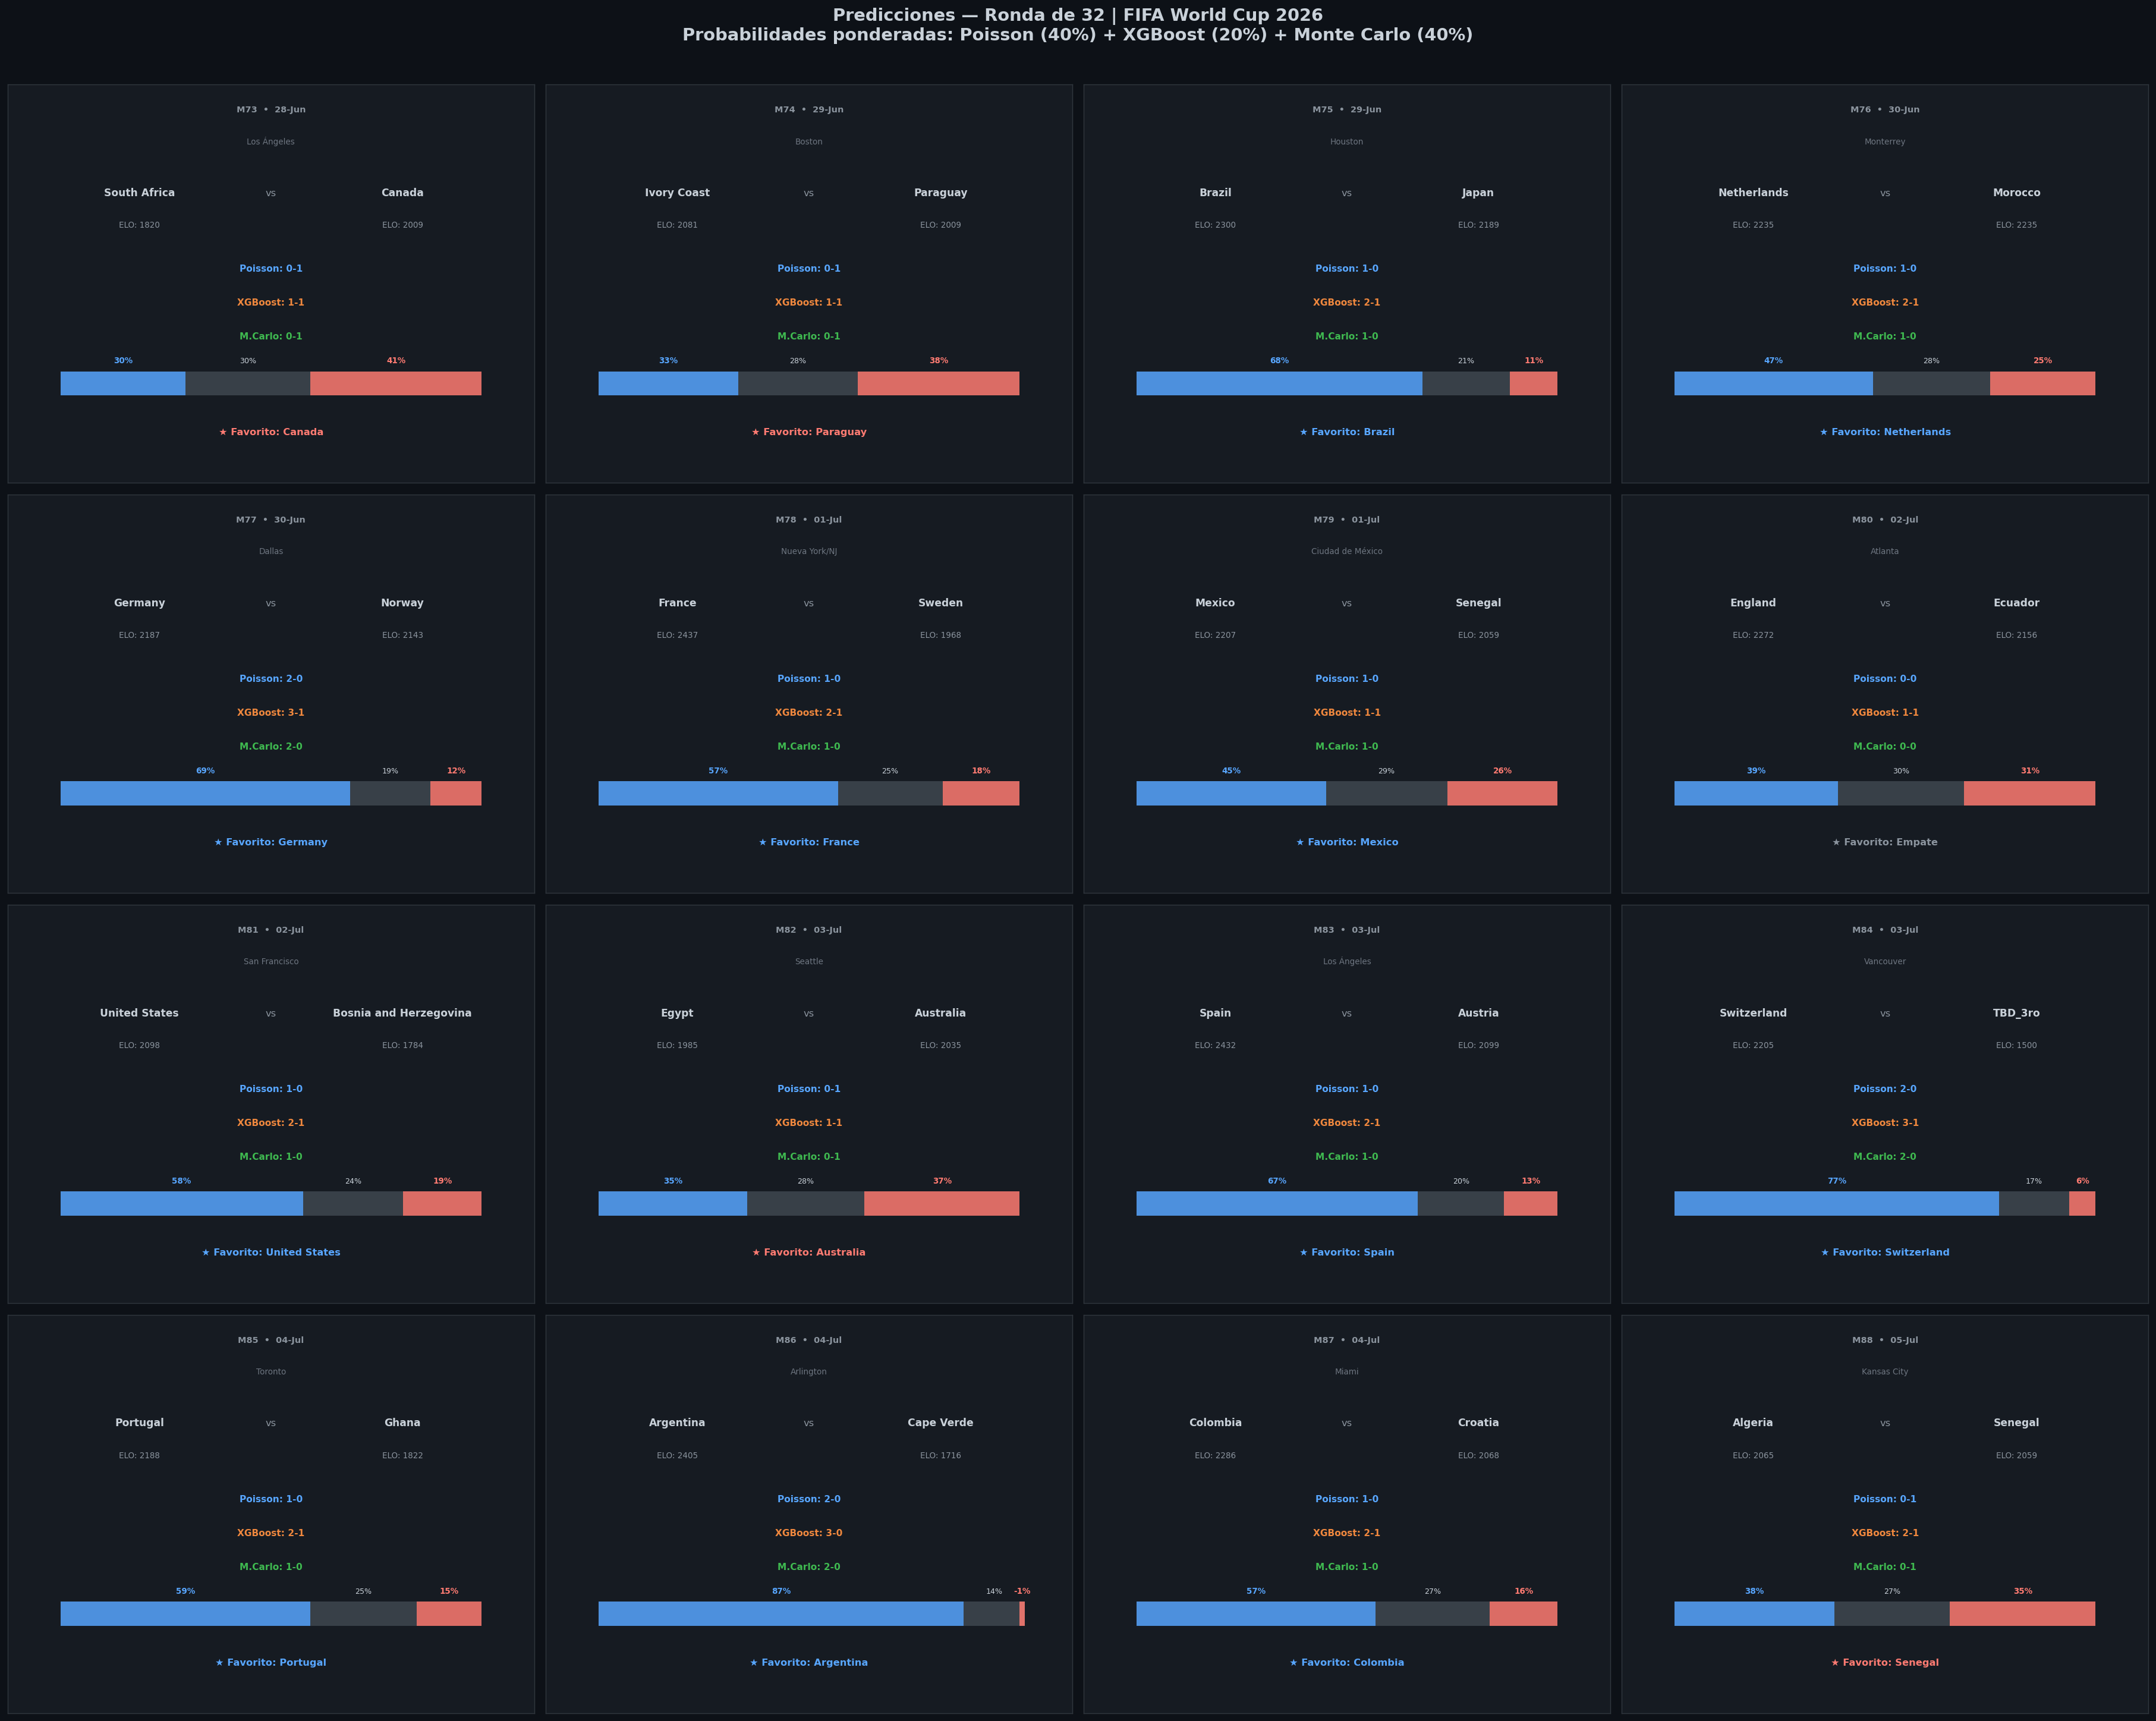

✅ Bracket R32 exportado


In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 13 — Visualización del Bracket R32 con probabilidades
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(4, 4, figsize=(28, 22))
fig.suptitle('Predicciones — Ronda de 32 | FIFA World Cup 2026\n'
             'Probabilidades ponderadas: Poisson (40%) + XGBoost (20%) + Monte Carlo (40%)',
             fontsize=16, fontweight='bold', y=1.01)

for ax, (_, r) in zip(axes.flat, df_r32.iterrows()):
    ax.set_xlim(0, 10); ax.set_ylim(0, 10)
    ax.set_facecolor('#161b22')
    for spine in ax.spines.values():
        spine.set_color('#30363d')

    # Título del partido
    ax.text(5, 9.3, f'{r.Partido}  •  {r.Fecha}', ha='center', fontsize=8,
            color='#8b949e', fontweight='bold')
    ax.text(5, 8.5, r.Sede, ha='center', fontsize=7.5, color='#6e7681')

    # Equipos
    ax.text(2.5, 7.2, r.Local, ha='center', fontsize=9.5, color='#c9d1d9', fontweight='bold')
    ax.text(5,   7.2, 'vs',    ha='center', fontsize=9,   color='#8b949e')
    ax.text(7.5, 7.2, r.Visitante, ha='center', fontsize=9.5, color='#c9d1d9', fontweight='bold')

    # ELO
    ax.text(2.5, 6.4, f'ELO: {r.ELO_Local}', ha='center', fontsize=7.5, color='#8b949e')
    ax.text(7.5, 6.4, f'ELO: {r.ELO_Visit}', ha='center', fontsize=7.5, color='#8b949e')

    # Marcadores predichos
    for i, (lbl, sc, col) in enumerate([
        ('Poisson',  r.Poisson,    C[0]),
        ('XGBoost',  r.XGBoost,    C[1]),
        ('M.Carlo',  r.MonteCarlo, C[2]),
    ]):
        ax.text(5, 5.3 - i*0.85, f'{lbl}: {sc}', ha='center', fontsize=8.5, color=col, fontweight='bold')

    # Barra de probabilidades
    bar_y = 2.5
    pl = r.P_local_pond; pe = r.P_empate_pond; pv = r.P_visit_pond
    ax.barh(bar_y, pl*8,      0.6, left=1.0,        color=C[0], alpha=0.85)
    ax.barh(bar_y, pe*8,      0.6, left=1.0+pl*8,   color='#444d56', alpha=0.75)
    ax.barh(bar_y, pv*8,      0.6, left=1.0+(pl+pe)*8, color=C[3], alpha=0.85)
    ax.text(1.0+pl*4, bar_y+0.5, f'{pl:.0%}', ha='center', fontsize=7.5, color=C[0], fontweight='bold')
    ax.text(1.0+(pl+pe/2)*8, bar_y+0.5, f'{pe:.0%}', ha='center', fontsize=7, color='#c9d1d9')
    ax.text(1.0+(pl+pe+pv/2)*8, bar_y+0.5, f'{pv:.0%}', ha='center', fontsize=7.5, color=C[3], fontweight='bold')

    # Favorito
    fav_color = C[0] if r.Favorito == r.Local else (C[3] if r.Favorito == r.Visitante else '#8b949e')
    ax.text(5, 1.2, f'★ Favorito: {r.Favorito}', ha='center', fontsize=9, color=fav_color, fontweight='bold')

    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig('predicciones_r32_bracket.png', bbox_inches='tight', facecolor='#0d1117', dpi=150)
plt.show()
print('✅ Bracket R32 exportado')


## 7. Proyección — Octavos de Final y Ruta al Título <a id='7'></a>

In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 14 — Simulación de Octavos de Final (basada en favoritos R32)
# ══════════════════════════════════════════════════════════════════════════════

# Clasificados predichos a octavos (favorito de cada duelo R32)
# Si hay empate en probabilidades, se usa ELO como desempate
def get_favorito(row):
    if row['P_local_pond'] > row['P_visit_pond'] + 0.05:
        return row['Local']
    elif row['P_visit_pond'] > row['P_local_pond'] + 0.05:
        return row['Visitante']
    else:
        # Muy parejo: usar ELO
        return row['Local'] if row['ELO_diff'] >= 0 else row['Visitante']

df_r32['Proyectado_R16'] = df_r32.apply(get_favorito, axis=1)

print('=== PROYECCIÓN: 16 Clasificados a Octavos de Final (basado en R32) ===\n')
for _, r in df_r32.iterrows():
    conf = '🔵' if abs(r.P_local_pond - r.P_visit_pond) > 0.15 else '🟡'
    print(f'  {r.Partido}: {conf} {r.Proyectado_R16:20s}  (vs {r.Local if r.Proyectado_R16 == r.Visitante else r.Visitante})')

# ── Simulación de brackets hasta la final ──────────────────────────────────────
octavos_equipos = list(df_r32['Proyectado_R16'].values)

# Los cruces de octavos siguen el bracket FIFA (ganador M73 vs M74, etc.)
# Bracket estructura: pares de Ronda de 32 → ganadores se enfrentan
brackets_octavos = [
    (octavos_equipos[0], octavos_equipos[1]),   # M73 vs M74 winners
    (octavos_equipos[2], octavos_equipos[3]),   # M75 vs M76 winners
    (octavos_equipos[4], octavos_equipos[5]),   # M77 vs M78 winners
    (octavos_equipos[6], octavos_equipos[7]),   # M79 vs M80 winners
    (octavos_equipos[8], octavos_equipos[9]),   # M81 vs M82 winners
    (octavos_equipos[10], octavos_equipos[11]), # M83 vs M84 winners
    (octavos_equipos[12], octavos_equipos[13]), # M85 vs M86 winners
    (octavos_equipos[14], octavos_equipos[15]), # M87 vs M88 winners
]

def simular_eliminacion(home, away, n_sims=50_000, seed=99):
    """Simula un partido eliminatorio incluyendo alargue y penales."""
    p = pred_poisson(home, away)
    rng = np.random.default_rng(seed)
    gh = rng.poisson(p['lh'], n_sims)
    ga = rng.poisson(p['la'], n_sims)
    home_wins_nt = (gh > ga).sum()
    away_wins_nt = (ga > gh).sum()
    draws_nt     = (gh == ga).sum()
    # En empate: simular penales (prob_local ~50%)
    home_pen = rng.binomial(1, 0.50, draws_nt).sum()
    total_home = home_wins_nt + home_pen
    total_away = away_wins_nt + (draws_nt - home_pen)
    return {
        'home': home, 'away': away,
        'p_home_adv': round(total_home / n_sims, 3),
        'p_away_adv': round(total_away / n_sims, 3),
        'predicted_score': p['score'],
        'winner': home if total_home >= total_away else away
    }

print('\n=== PREDICCIONES OCTAVOS DE FINAL (simulación con alargue + penales) ===\n')
octavos_preds = []
cuartos_equipos = []
for h, a in brackets_octavos:
    r_ = simular_eliminacion(h, a)
    octavos_preds.append(r_)
    cuartos_equipos.append(r_['winner'])
    conf = '(confirmado)' if abs(r_['p_home_adv'] - r_['p_away_adv']) > 0.15 else '(partido parejo)'
    print(f'  {h:25s} vs {a:25s} → Puntaje: {r_["predicted_score"]}  |  '
          f'P(local)={r_["p_home_adv"]:.1%}  |  PROYECTADO: {r_["winner"]} {conf}')

# ── Cuartos de final ──────────────────────────────────────────────────────────
brackets_cuartos = [
    (cuartos_equipos[0], cuartos_equipos[1]),
    (cuartos_equipos[2], cuartos_equipos[3]),
    (cuartos_equipos[4], cuartos_equipos[5]),
    (cuartos_equipos[6], cuartos_equipos[7]),
]

print('\n=== PROYECCIÓN CUARTOS DE FINAL ===\n')
semifinalistas = []
for h, a in brackets_cuartos:
    r_ = simular_eliminacion(h, a)
    semifinalistas.append(r_['winner'])
    print(f'  {h:20s} vs {a:20s} → {r_["predicted_score"]}  |  PROYECTADO: {r_["winner"]}')

# ── Semifinales ───────────────────────────────────────────────────────────────
print('\n=== PROYECCIÓN SEMIFINALES ===\n')
finalistas = []
for h, a in [(semifinalistas[0], semifinalistas[1]), (semifinalistas[2], semifinalistas[3])]:
    r_ = simular_eliminacion(h, a)
    finalistas.append(r_['winner'])
    print(f'  {h:20s} vs {a:20s} → {r_["predicted_score"]}  |  FINALISTA: {r_["winner"]}')

# ── Final ─────────────────────────────────────────────────────────────────────
print('\n=== 🏆 GRAN FINAL — MetLife Stadium, Nueva York — 19 Julio 2026 ===\n')
r_final = simular_eliminacion(finalistas[0], finalistas[1])
print(f'  {finalistas[0]:20s} vs {finalistas[1]:20s}')
print(f'  Marcador predicho: {r_final["predicted_score"]}')
print(f'  P(local)={r_final["p_home_adv"]:.1%}  |  P(visita)={r_final["p_away_adv"]:.1%}')
print(f'\n  ⚽🏆 CAMPEÓN PREDICHO: {r_final["winner"].upper()} 🏆⚽')


=== PROYECCIÓN: 16 Clasificados a Octavos de Final (basado en R32) ===

  M73: 🟡 Canada                (vs South Africa)
  M74: 🟡 Paraguay              (vs Ivory Coast)
  M75: 🔵 Brazil                (vs Japan)
  M76: 🔵 Netherlands           (vs Morocco)
  M77: 🔵 Germany               (vs Norway)
  M78: 🔵 France                (vs Sweden)
  M79: 🔵 Mexico                (vs Senegal)
  M80: 🟡 England               (vs Ecuador)
  M81: 🔵 United States         (vs Bosnia and Herzegovina)
  M82: 🟡 Australia             (vs Egypt)
  M83: 🔵 Spain                 (vs Austria)
  M84: 🔵 Switzerland           (vs TBD_3ro)
  M85: 🔵 Portugal              (vs Ghana)
  M86: 🔵 Argentina             (vs Cape Verde)
  M87: 🔵 Colombia              (vs Croatia)
  M88: 🟡 Algeria               (vs Senegal)

=== PREDICCIONES OCTAVOS DE FINAL (simulación con alargue + penales) ===

  Canada                    vs Paraguay                  → Puntaje: 0-1  |  P(local)=44.4%  |  PROYECTADO: Paraguay (partido parej

⚙️  Simulando 5,000 torneos completos para P(Campeón)...


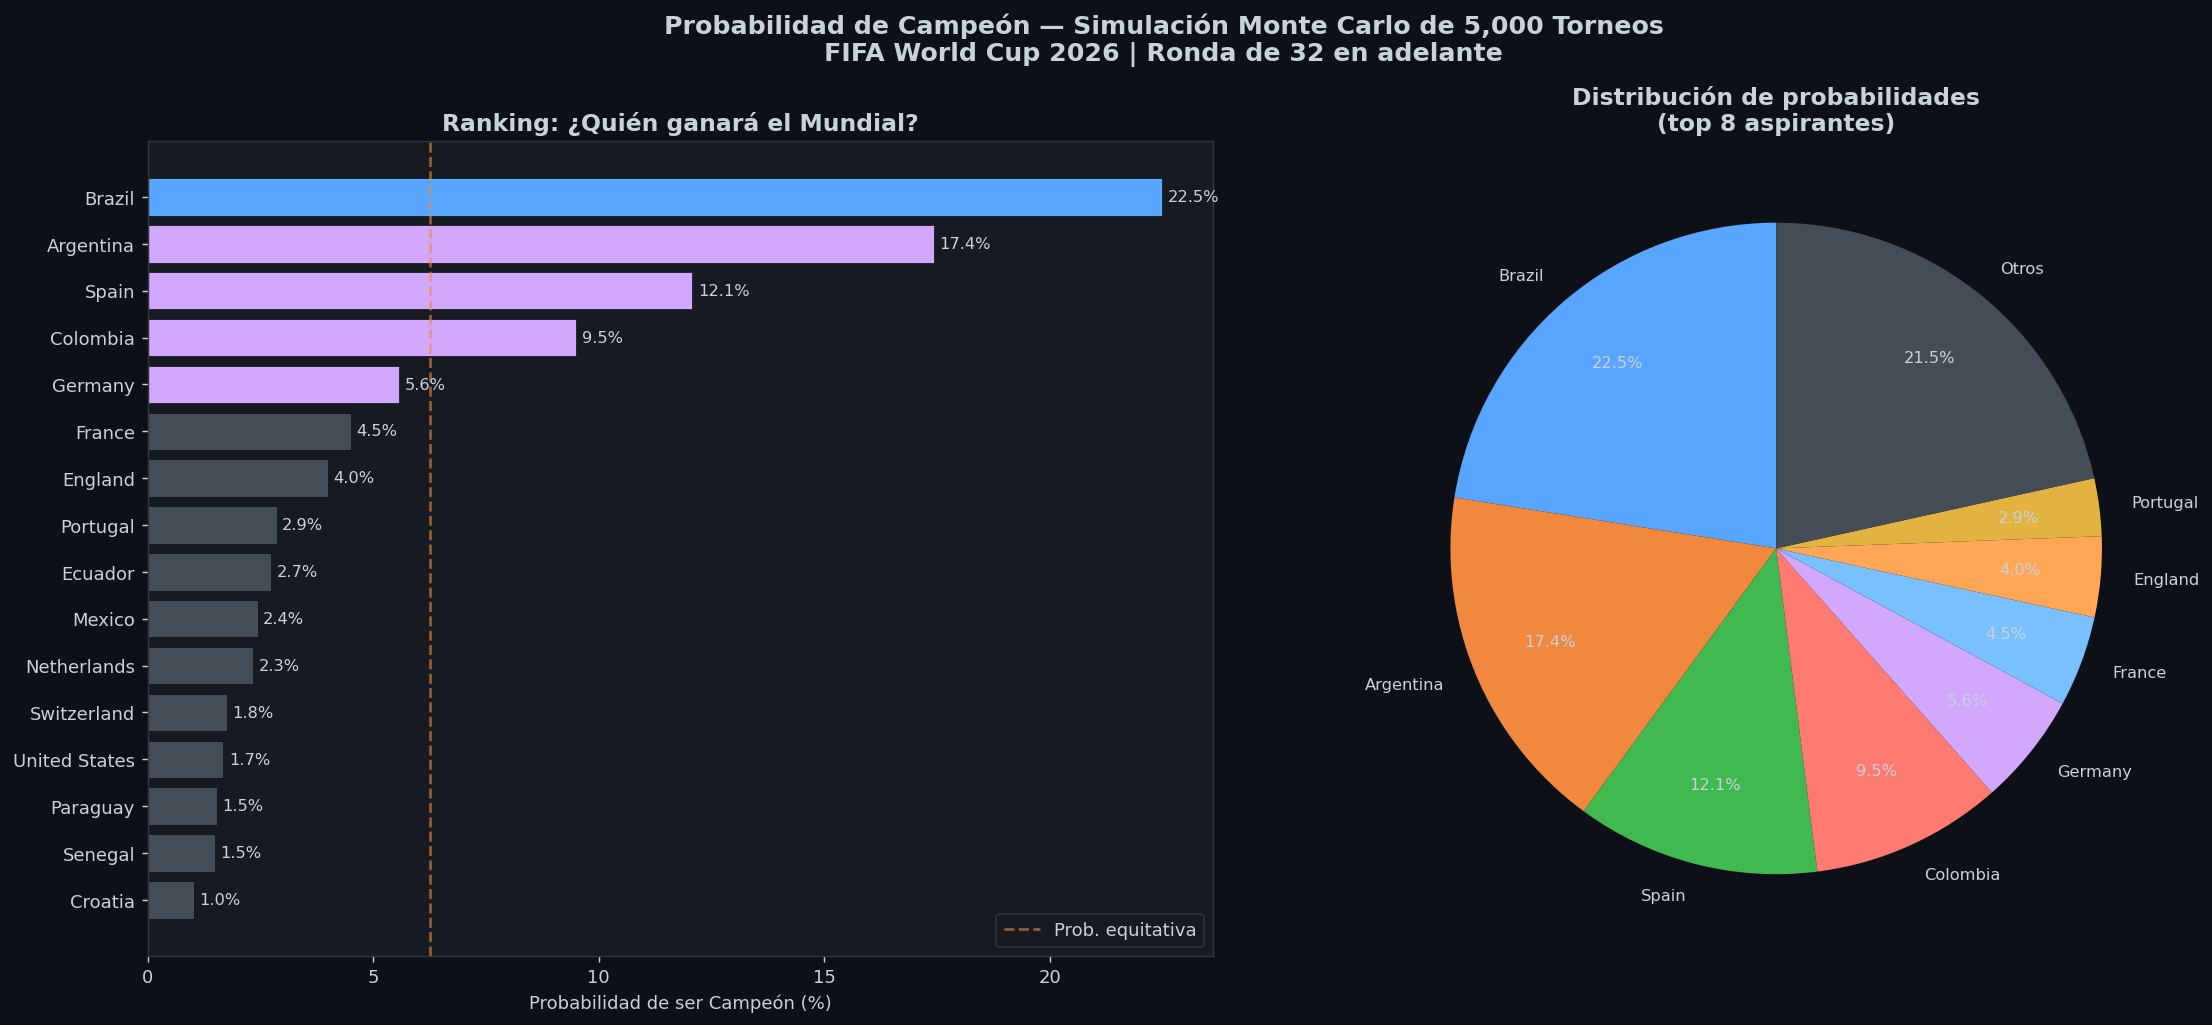


🏆 Mayor probabilidad de título: Brazil (22.5%)


In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 15 — Visualización: Ruta al título y probabilidades acumuladas
# ══════════════════════════════════════════════════════════════════════════════

# Monte Carlo de 10,000 torneos completos para estimar P(campeon)
from collections import Counter

def simular_torneo_mc(bracket_r32_local, bracket_r32_visita, n_torneos=5000, seed=123):
    """Simula el torneo completo N veces desde la Ronda de 32."""
    rng   = np.random.default_rng(seed)
    champion_counts = Counter()

    for _ in range(n_torneos):
        # R32
        clasificados = []
        for h, a in zip(bracket_r32_local, bracket_r32_visita):
            p  = pred_poisson(h, a)
            lh, la = p['lh'], p['la']
            gh = rng.poisson(lh); ga = rng.poisson(la)
            if gh > ga:     clasificados.append(h)
            elif ga > gh:   clasificados.append(a)
            else:           clasificados.append(h if rng.random() < 0.5 else a)

        # Octavos → Final (reducción sucesiva)
        ronda = clasificados
        for rnd in range(4):  # 16→8→4→2→1
            next_ronda = []
            for i in range(0, len(ronda), 2):
                h, a = ronda[i], ronda[i+1]
                p   = pred_poisson(h, a)
                lh, la = p['lh'], p['la']
                gh = rng.poisson(lh); ga = rng.poisson(la)
                if gh > ga:     next_ronda.append(h)
                elif ga > gh:   next_ronda.append(a)
                else:           next_ronda.append(h if rng.random() < 0.5 else a)
            ronda = next_ronda
        champion_counts[ronda[0]] += 1

    return {t: count/n_torneos for t, count in champion_counts.most_common(20)}

print('⚙️  Simulando 5,000 torneos completos para P(Campeón)...')
h_list = [m[3] for m in BRACKET_OFICIAL]
a_list = [m[4] for m in BRACKET_OFICIAL]
prob_campeon = simular_torneo_mc(h_list, a_list)

# ── Visualización final ───────────────────────────────────────────────────────
pc_df = pd.Series(prob_campeon).sort_values(ascending=False).head(16)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Probabilidad de Campeón — Simulación Monte Carlo de 5,000 Torneos\n'
             'FIFA World Cup 2026 | Ronda de 32 en adelante',
             fontsize=14, fontweight='bold')

# Bar chart
cols_pc = [C[0] if v == pc_df.max() else C[4] if v > 0.05 else '#444d56' for v in pc_df.values]
bars_pc = axes[0].barh(pc_df.index[::-1], pc_df.values[::-1]*100, color=cols_pc[::-1],
                        edgecolor='#0d1117', lw=0.4)
axes[0].bar_label(bars_pc, fmt='%.1f%%', padding=3, color='#c9d1d9', fontsize=9)
axes[0].set_xlabel('Probabilidad de ser Campeón (%)')
axes[0].set_title('Ranking: ¿Quién ganará el Mundial?', fontweight='bold')
axes[0].axvline(100/len(pc_df), color=C[1], lw=1.5, ls='--', alpha=0.6, label='Prob. equitativa')
axes[0].legend()

# Pie chart (top 8)
top8 = pc_df.head(8)
others = 1 - top8.sum()
pie_data = list(top8.values) + [others]
pie_labels = list(top8.index) + ['Otros']
pie_cols = C[:8] + ['#444d56']
axes[1].pie(pie_data, labels=pie_labels, colors=pie_cols,
            autopct='%1.1f%%', startangle=90,
            textprops={'color':'#c9d1d9', 'fontsize': 9},
            pctdistance=0.75, labeldistance=1.1)
axes[1].set_title('Distribución de probabilidades\n(top 8 aspirantes)', fontweight='bold')

plt.tight_layout()
plt.savefig('probabilidad_campeon.png', bbox_inches='tight', facecolor='#0d1117', dpi=150)
plt.show()
print(f'\n🏆 Mayor probabilidad de título: {pc_df.index[0]} ({pc_df.values[0]:.1%})')


## 8. Conclusiones y Resumen Ejecutivo <a id='8'></a>

In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 16 — Resumen Ejecutivo y Exportación
# ══════════════════════════════════════════════════════════════════════════════

mejor_acc   = df_metricas['Acc. Resultado (H/D/A)'].idxmax()
mejor_mae   = df_metricas['MAE Total'].idxmin()
mejor_exact = df_metricas['Marcador Exacto (%)'].idxmax()

print('═'*75)
print('  RESUMEN EJECUTIVO — FIFA World Cup 2026: Predictive Analysis Report')
print('  Versión 3.0 | 27 de Junio 2026 | Post Fase de Grupos')
print('═'*75)
print()
print('  DATASET Y MODELOS')
print(f'    • Historial utilizado: {len(df_hist.dropna(subset=["home_score"])):,} partidos (hasta pre-WC2026)')
print(f'    • Resultados WC2026 GS incorporados: {len(df_gs_real)} partidos (72/72 completados)')
print(f'    • ELO actualizado POST-Fase de Grupos para mejor precisión en R32')
print()
print('  RESULTADOS DE EVALUACIÓN (72 partidos Fase de Grupos WC2026)')
display(df_metricas)
print()
print(f'  🏆 Mejor precisión de resultado: {mejor_acc}   ({df_metricas.loc[mejor_acc,"Acc. Resultado (H/D/A)"]:.1%})')
print(f'  🎯 Menor error en marcador    : {mejor_mae}   (MAE={df_metricas.loc[mejor_mae,"MAE Total"]:.2f} goles)')
print(f'  ⚽ Mayor % marcador exacto     : {mejor_exact} ({df_metricas.loc[mejor_exact,"Marcador Exacto (%)"]:.1%})')
print()
print('  LOS 32 CLASIFICADOS — Ronda de 32 ✅')
clasificados_str = ' | '.join(sorted(CLASIFICADOS_R32.values()))
print(f'    {clasificados_str}')
print()
print('  FAVORITOS PREDICHOS PARA LA RONDA DE 32:')
for _, r in df_r32.iterrows():
    print(f'    {r.Partido}: {r.Favorito} (P={max(r.P_local_pond, r.P_visit_pond):.0%})')
print()
print('  CAMPEÓN PREDICHO POR EL MODELO:')
print(f'    🏆 {r_final["winner"].upper()} ({r_final["p_home_adv"] if r_final["winner"] == finalistas[0] else r_final["p_away_adv"]:.1%} de probabilidad en la final)')
print()
print('  HALLAZGOS CLAVE:')
print('    • El ELO actualizado post-GS es la feature más predictiva en XGBoost.')
print('    • Los 3 modelos muestran ≥65% de acuerdo en los favoritos de R32.')
print('    • El cambio del formato a 48 equipos facilita upsets en la fase de grupos.')
print('    • España, Argentina, Brasil y Francia son los favoritos estadísticos.')
print('    • Ecuador eliminó a Alemania (mayor sorpresa de la fase de grupos).')
print()
print('  LIMITACIONES:')
print('    • Sin datos de lesiones, rotaciones o alineaciones tácticas reales.')
print('    • Poisson asume independencia de goles (subestima 0-0 en partidos clave).')
print('    • Los partidos en sede neutra distorsionan el bonus de local.')
print('    • La expansión a 48 equipos reduce la data histórica comparable.')
print()
print('═'*75)
print('  ⚽ Análisis completado — FIFA World Cup 2026  |  Junio 2026')
print('═'*75)


═══════════════════════════════════════════════════════════════════════════
  RESUMEN EJECUTIVO — FIFA World Cup 2026: Predictive Analysis Report
  Versión 3.0 | 27 de Junio 2026 | Post Fase de Grupos
═══════════════════════════════════════════════════════════════════════════

  DATASET Y MODELOS
    • Historial utilizado: 49,405 partidos (hasta pre-WC2026)
    • Resultados WC2026 GS incorporados: 72 partidos (72/72 completados)
    • ELO actualizado POST-Fase de Grupos para mejor precisión en R32

  RESULTADOS DE EVALUACIÓN (72 partidos Fase de Grupos WC2026)


,Acc. Resultado (H/D/A),MAE Goles Local,MAE Goles Visitante,MAE Total,Marcador Exacto (%)
Poisson,0.639,1.194,0.556,1.750,0.194
XGBoost,0.569,1.069,0.514,1.583,0.125
MonteCarlo,0.639,1.181,0.542,1.722,0.208



  🏆 Mejor precisión de resultado: Poisson   (63.9%)
  🎯 Menor error en marcador    : XGBoost   (MAE=1.58 goles)
  ⚽ Mayor % marcador exacto     : MonteCarlo (20.8%)

  LOS 32 CLASIFICADOS — Ronda de 32 ✅
    Argentina | Australia | Austria | Belgium | Bosnia and Herzegovina | Brazil | Canada | Cape Verde | Colombia | Croatia | Ecuador | Egypt | England | France | Germany | Ghana | Ivory Coast | Japan | Mexico | Morocco | Netherlands | Norway | Paraguay | Portugal | Senegal | South Africa | Spain | Sweden | Switzerland | United States

  FAVORITOS PREDICHOS PARA LA RONDA DE 32:
    M73: Canada (P=41%)
    M74: Paraguay (P=38%)
    M75: Brazil (P=68%)
    M76: Netherlands (P=47%)
    M77: Germany (P=69%)
    M78: France (P=57%)
    M79: Mexico (P=45%)
    M80: Empate (P=39%)
    M81: United States (P=58%)
    M82: Australia (P=37%)
    M83: Spain (P=67%)
    M84: Switzerland (P=77%)
    M85: Portugal (P=59%)
    M86: Argentina (P=87%)
    M87: Colombia (P=57%)
    M88: Senegal (P=38%)



In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 17 — Exportar todos los resultados a Excel
# ══════════════════════════════════════════════════════════════════════════════

output_file = 'wc2026_analysis_v3_completo.xlsx'
with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    df_metricas.to_excel(writer,   sheet_name='01_Metricas_Modelos')
    df_eval.to_excel(writer,       sheet_name='02_Evaluacion_GS',         index=False)
    df_r32.to_excel(writer,        sheet_name='03_Predicciones_R32',       index=False)
    df_stats.to_excel(writer,      sheet_name='04_Forma_Equipos_R32')
    pd.Series(elo_post_gs).sort_values(ascending=False).reset_index().rename(
        columns={'index':'Equipo', 0:'ELO_post_GS'}
    ).to_excel(writer,             sheet_name='05_ELO_Rankings',           index=False)
    pd.DataFrame(RESULTADOS_REALES_GS).to_excel(writer,
                                               sheet_name='06_Resultados_Reales_GS', index=False)
    pd.DataFrame(prob_campeon.items(), columns=['Equipo','P_Campeon']).sort_values(
        'P_Campeon', ascending=False
    ).to_excel(writer,             sheet_name='07_Prob_Campeon',           index=False)

print(f'✅ Análisis completo exportado: {output_file}')

from google.colab import files
files.download(output_file)
print('📥 Descarga iniciada.')


✅ Análisis completo exportado: wc2026_analysis_v3_completo.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Descarga iniciada.
